# AgroPlus - Modelo L2 LLP-Co (CRISP-DM)

Notebook dedicado al **modelo de clasificacion de cultivos por proporciones (LLP-Co)** para la capa L2 del ensamble jerarquico de AgroPlus.

**Objetivo:** entrenar y afinar un modelo basado en *La Rosa et al. (2022) - Learning from Label Proportions with Prototypical Contrastive Clustering* sobre la vista minable, usando como prior las proporciones agregadas de la Evaluacion Agropecuaria Municipal (EVA) de Cundinamarca.

**Pipeline:**
1. Preparacion de datos - filtrado a L2 EVA, mascara agricola, soft labels.
2. Bags dinamicos por municipio (sampleo aleatorio cada epoch).
3. Encoder MLP + Prototipos + Sinkhorn-Knopp con restriccion de proporcion.
4. Evaluacion: KL divergence por bag, F1 macro pixel, prototipos.
5. Ajuste de hiperparametros.


---

# PASO 1 — Modelo L2 EVA con LLP-Co

## Objetivo
Entrenar un clasificador a nivel de pixel usando solo proporciones de cultivo por municipio (etiqueta débil tipo LLP).

**Algoritmo 1 del paper, adaptado a tabular:**
- Encoder MLP: features tabulares → embedding **512** normalizado L2 (en lugar de ResNet18 sobre patches).
- Augmentaciones: feature dropout + ruido gaussiano (hiperparámetros optimizados via Optuna) para generar 2 vistas por pixel.
- Prototipos `V` ∈ ℝ^{K × 512} entrenables, **K=18** (una por clase L2).
- Códigos `Q^s, Q^t` por Sinkhorn-Knopp restringidos a `wᵢ` (proporciones EVA del bag).
- Pérdida swap entre las dos vistas (eq. 7-9 del paper).

**Bags:** un bag por municipio (~81 bags/epoch en entrenamiento, BAG_SIZE=2048 píxeles).


## 1.1 Instalación de dependencias

In [1]:
# Instalacion completa de dependencias del notebook ensamble.
# Cubre: numerico, viz, ML clasico, XGBoost, PyTorch, balanceo, optimizacion bayesiana.
# Nota: para PyTorch CUDA usar el comando especifico de https://pytorch.org/

%pip install -q "numpy>=1.24" "pandas>=2.0" "pyarrow>=14" "matplotlib>=3.8" "seaborn>=0.13" "scikit-learn>=1.4" "xgboost>=2.0" "imbalanced-learn>=0.12" "optuna>=3.6" "optuna-integration[sklearn]>=3.6" "torch>=2.0" "tqdm>=4.66" "nbformat>=5.9" "ipykernel>=6.29"

print("Dependencias instaladas. Reinicia el kernel si pytorch o matplotlib se actualizo.")


Note: you may need to restart the kernel to use updated packages.
Dependencias instaladas. Reinicia el kernel si pytorch o matplotlib se actualizo.


## 1.2 Imports

In [2]:
# Compatibilidad matplotlib >= 3.9: MatplotlibDeprecationWarning fue eliminada.
import matplotlib._api as _mpl_api_compat
if not hasattr(_mpl_api_compat, 'MatplotlibDeprecationWarning'):
    class MatplotlibDeprecationWarning(DeprecationWarning):
        pass
    _mpl_api_compat.MatplotlibDeprecationWarning = MatplotlibDeprecationWarning

# Suppression de warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Stdlib
import os, json, collections, time
from pathlib import Path

# Numericas / DataFrames
import numpy as np
import pandas as pd

# Visualizacion
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
mpl.style.use('ggplot')
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
%matplotlib inline

# Preprocesamiento
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, LabelEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# Splits
from sklearn.model_selection import GroupShuffleSplit

# Metricas
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, log_loss
)

# Modelos clasicos
from xgboost import XGBClassifier
import xgboost as xgb

# PyTorch (LLP-Co)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Reproducibilidad
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f"NumPy {np.__version__}, Pandas {pd.__version__}, "
      f"PyTorch {torch.__version__} (CUDA={torch.cuda.is_available()}), "
      f"XGBoost {xgb.__version__}")


NumPy 2.4.4, Pandas 3.0.2, PyTorch 2.11.0+cu126 (CUDA=True), XGBoost 3.2.0


In [3]:
# --- Dispositivos ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch device: {DEVICE}")

# XGBoost device
try:
    import subprocess
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    XGB_DEVICE = 'cuda' if result.returncode == 0 else 'cpu'
except Exception:
    XGB_DEVICE = 'cpu'
XGB_TREE_METHOD = 'hist'
print(f"XGBoost device: {XGB_DEVICE}")


PyTorch device: cuda
XGBoost device: cuda


---
## 2. Comprensión de los Datos

Carga de la vista minable, catálogo y filtrado a las filas L2 EVA. El catálogo L2 tiene **18 clases** (todas las de EVA municipal excepto `No_apto` y `Otros_cultivos`, que quedan bajo responsabilidad del modelo L3).


In [4]:
# Rutas locales
DATA_DIR = Path('../vista_minable')
CKPT_DIR = Path('checkpoints')
CKPT_DIR.mkdir(exist_ok=True)

DATA_PATH = DATA_DIR / 'vista_minable_full.parquet'
CATALOGO_PATH = DATA_DIR / 'catalogo_cultivos.json'

print(f"Vista minable: {DATA_PATH} ({DATA_PATH.stat().st_size / 1e6:.1f} MB)")
print(f"Catalogo:      {CATALOGO_PATH}")


Vista minable: ..\vista_minable\vista_minable_full.parquet (614.9 MB)
Catalogo:      ..\vista_minable\catalogo_cultivos.json


In [5]:
# Cargar vista minable y catalogo
df_raw = pd.read_parquet(DATA_PATH)
print(f"Vista minable: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")

with open(CATALOGO_PATH, 'r', encoding='utf-8') as f:
    catalogo_full = json.load(f)
inv_catalogo_full = {v: k for k, v in catalogo_full.items()}
print(f"Catalogo original: {len(catalogo_full)} clases -> {list(catalogo_full.keys())}")


Vista minable: 4,165,215 filas x 77 columnas
Catalogo original: 20 clases -> ['Papa', 'Cana_Panelera', 'Cafe', 'Maiz', 'Platano', 'Mango', 'Frijol', 'Cacao', 'Arveja', 'Palma', 'Banano', 'Citricos', 'Mora', 'Zanahoria', 'Tomate_Arbol', 'Yuca', 'Habichuela', 'Hortalizas', 'Otros_cultivos', 'No_apto']


In [6]:
# === Catalogo final L2: 18 clases ===
# Papa se incluye: las proporciones EVA de Papa se asignan como senal debil
# (LLP) a todos los pixeles del municipio, incluidos los de monitoreo UPRA.
# Los pixeles UPRA conservan fuente='monitoreo' y cultivo='Papa' para
# validacion externa de las predicciones de LLP-Co.
# No_apto lo cubre el modelo L3 (proxy SIPRA+NDVI).
CLASES_FINALES = [
    'Cana_Panelera', 'Cafe', 'Maiz', 'Platano', 'Mango',
    'Frijol', 'Cacao', 'Arveja', 'Palma', 'Banano', 'Citricos',
    'Mora', 'Zanahoria', 'Tomate_Arbol', 'Yuca', 'Habichuela',
    'Hortalizas', 'Papa',
]
catalogo = {c: i for i, c in enumerate(CLASES_FINALES)}
inv_catalogo = {i: c for c, i in catalogo.items()}
K_FINAL = len(CLASES_FINALES)
print(f"Catalogo L2 final: {K_FINAL} clases (No_apto -> L3)")
for k, v in catalogo.items():
    print(f"  [{v:2d}] {k}")

Catalogo L2 final: 18 clases (No_apto -> L3)
  [ 0] Cana_Panelera
  [ 1] Cafe
  [ 2] Maiz
  [ 3] Platano
  [ 4] Mango
  [ 5] Frijol
  [ 6] Cacao
  [ 7] Arveja
  [ 8] Palma
  [ 9] Banano
  [10] Citricos
  [11] Mora
  [12] Zanahoria
  [13] Tomate_Arbol
  [14] Yuca
  [15] Habichuela
  [16] Hortalizas
  [17] Papa


In [7]:
# === Distribucion por nivel de etiquetado ===
fuentes = df_raw['fuente'].value_counts()
print("Pixeles por nivel:")
print(fuentes.to_string())
print()
print("Pixeles por (fuente, cultivo):")
print(df_raw.groupby(['fuente', 'cultivo']).size().unstack(fill_value=0))


Pixeles por nivel:
fuente
eva_municipal    2998317
noapto_proxy      600869
monitoreo         566029

Pixeles por (fuente, cultivo):
cultivo        Arveja  Banano  Cacao    Cafe  Cana_Panelera  Citricos  Frijol  \
fuente                                                                          
eva_municipal    2760   13535  28667  184425          56294     19557  106063   
monitoreo           0       0      0       0              0         0       0   
noapto_proxy        0       0      0       0              0         0       0   

cultivo        Habichuela  Hortalizas    Maiz  Mango   Mora  No_apto  \
fuente                                                                 
eva_municipal       13405      234338  164188   9654  33062        0   
monitoreo               0           0       0      0      0        0   
noapto_proxy            0           0       0      0      0   600869   

cultivo        Otros_cultivos  Palma     Papa  Platano   Yuca  
fuente                              

FICHA TECNICA: vista_minable_full.parquet
  Filas totales:       4,165,215
  Columnas totales:           77
  Semestres:                   9
  Municipios:                113
  Pixeles unicos:      4,165,215

  Columnas meta:      5
  Columnas feature:   47
  Columnas prob_*:    20 (soft labels EVA)
  Columnas target:    5

Muestra de 8 filas (columnas clave):
semestre  cod_mun        fuente cultivo  confianza  elevacion  pendiente  sg_soc  chirps_acum  s2_ndvi_max  s2_gndvi_max  temperatura_media
   2023B    25873 eva_municipal    Papa     0.7000  3154.3711    25.2934  8.4900     351.9296       0.5713        0.5767            -3.5572
   2022A    25793 eva_municipal    Papa     0.7000  2912.9893    15.2442  8.7600     557.2138       0.6019        0.6013            -6.3277
   2022B    25200 eva_municipal    Papa     0.7000  2833.5518    11.4484  7.3000     791.0725       0.8600        0.7261            -7.6496
   2022B    25513 eva_municipal    Cafe     0.7000  1683.6603    54.7673  8.61

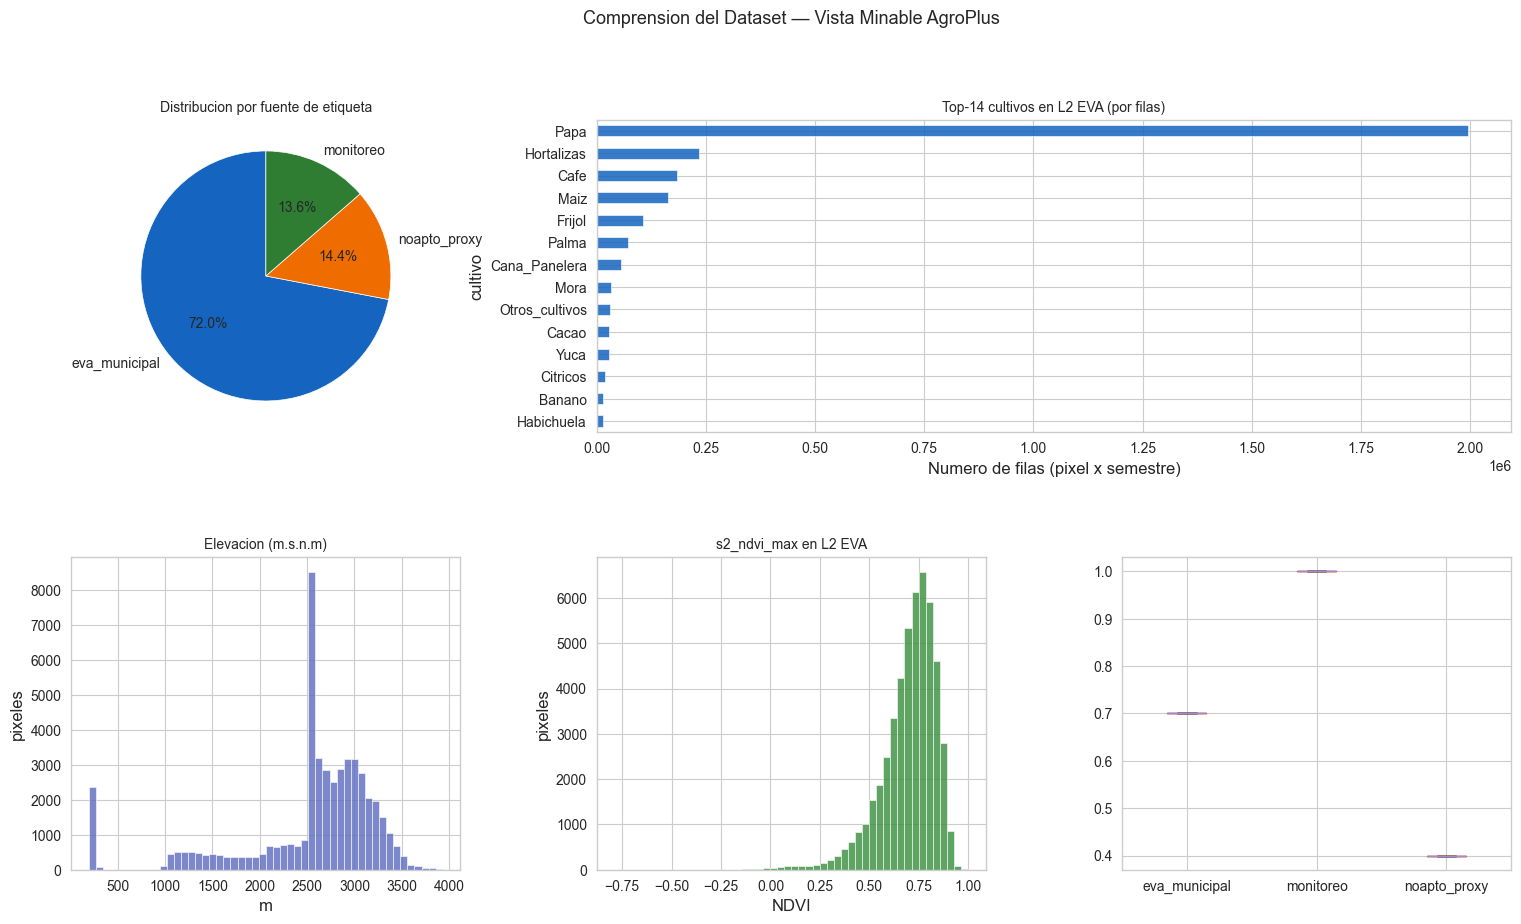

In [8]:
# === Muestra del dataset: comprension de la vista minable ===
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# --- 1. Ficha tecnica del dataset ---
print('=' * 65)
print('FICHA TECNICA: vista_minable_full.parquet')
print('=' * 65)
print(f'  Filas totales:      {len(df_raw):>10,}')
print(f'  Columnas totales:   {df_raw.shape[1]:>10}')
print(f'  Semestres:          {df_raw["semestre"].nunique():>10}')
print(f'  Municipios:         {df_raw["cod_mun"].nunique():>10}')
print(f'  Pixeles unicos:     {df_raw["pixel_id"].nunique():>10,}')
print()

# Columnas por tipo
meta  = ['pixel_id','x','y','semestre','cod_mun']
targ  = ['cultivo','cultivo_id','confianza','fuente','rendimiento_tha']
probs = [c for c in df_raw.columns if c.startswith('prob_')]
feats = [c for c in df_raw.columns if c not in meta+targ+probs]
print(f'  Columnas meta:      {len(meta)}')
print(f'  Columnas feature:   {len(feats)}')
print(f'  Columnas prob_*:    {len(probs)} (soft labels EVA)')
print(f'  Columnas target:    {len(targ)}')
print()

# --- 2. Muestra de 8 filas con columnas clave ---
COLS_MUESTRA = [
    'semestre', 'cod_mun', 'fuente', 'cultivo', 'confianza',
    'elevacion', 'pendiente', 'sg_soc', 'chirps_acum',
    's2_ndvi_max', 's2_gndvi_max', 'temperatura_media',
]
cols_ok = [c for c in COLS_MUESTRA if c in df_raw.columns]
print('Muestra de 8 filas (columnas clave):')
sample = df_raw[cols_ok].sample(8, random_state=42)
print(sample.to_string(index=False))
print()

# --- 3. Estadisticas descriptivas de features numericas ---
NUM_FEATS_SHOW = [
    'elevacion', 'pendiente', 'twi',
    'sg_soc', 'sg_phh2o', 'sg_clay', 'sg_sand', 'sg_silt',
    'temperatura_media', 'chirps_acum', 'humedad_media',
    's2_ndvi_max', 's2_gndvi_max', 's2_bsi_max', 'ndvi_integral',
]
num_ok = [c for c in NUM_FEATS_SHOW if c in df_raw.columns]
print('Estadisticas descriptivas (muestra 50k filas):')
desc = df_raw[num_ok].sample(min(50_000, len(df_raw)), random_state=42).describe().T
desc = desc[['mean','std','min','25%','50%','75%','max']].round(3)
print(desc.to_string())
print()

# --- 4. Graficos de distribucion por fuente y clase ---
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 4a. Pie de fuentes
ax0 = fig.add_subplot(gs[0, 0])
fuente_cnt = df_raw['fuente'].value_counts()
ax0.pie(fuente_cnt, labels=fuente_cnt.index, autopct='%1.1f%%',
        colors=['#1565C0','#EF6C00','#2E7D32'], startangle=90)
ax0.set_title('Distribucion por fuente de etiqueta', fontsize=10)

# 4b. Barras de cultivo (top-12)
ax1 = fig.add_subplot(gs[0, 1:])
cult_cnt = df_raw[df_raw['fuente']=='eva_municipal']['cultivo'].value_counts().head(14)
cult_cnt.plot.barh(ax=ax1, color='#1565C0', alpha=0.85)
ax1.set_title('Top-14 cultivos en L2 EVA (por filas)', fontsize=10)
ax1.set_xlabel('Numero de filas (pixel x semestre)')
ax1.invert_yaxis()

# 4c. Histograma elevacion
ax2 = fig.add_subplot(gs[1, 0])
if 'elevacion' in df_raw.columns:
    df_raw['elevacion'].dropna().sample(50_000, random_state=42).hist(
        ax=ax2, bins=50, color='#5C6BC0', alpha=0.8)
ax2.set_title('Elevacion (m.s.n.m)', fontsize=10)
ax2.set_xlabel('m'); ax2.set_ylabel('pixeles')

# 4d. Histograma NDVI_max
ax3 = fig.add_subplot(gs[1, 1])
ndvi_col = next((c for c in ['s2_ndvi_max','ndvi_max'] if c in df_raw.columns), None)
if ndvi_col:
    df_raw[df_raw['fuente']=='eva_municipal'][ndvi_col].dropna() \
        .sample(50_000, random_state=42).hist(ax=ax3, bins=50, color='#388E3C', alpha=0.8)
ax3.set_title(f'{ndvi_col} en L2 EVA', fontsize=10)
ax3.set_xlabel('NDVI'); ax3.set_ylabel('pixeles')

# 4e. Boxplot confianza por fuente
ax4 = fig.add_subplot(gs[1, 2])
df_raw.boxplot(column='confianza', by='fuente', ax=ax4)
ax4.set_title('Confianza por fuente', fontsize=10)
ax4.set_xlabel(''); plt.sca(ax4); plt.title('')

plt.suptitle('Comprension del Dataset — Vista Minable AgroPlus', fontsize=13, y=1.01)
plt.show()


---
## 3. Preparacion de Datos para L2 LLP-Co

Filtrar a `fuente=='eva_municipal'`, construir W_norm (**18 clases**, excluyendo solo `prob_Otros_cultivos` y `prob_No_apto`),
reclasificar píxeles con argmax=Otros_cultivos via argmax(W_L2), y armar bags por municipio.


In [9]:
# === Filtrar a L2: EVA municipal + monitoreo UPRA ===
# - eva_municipal: distribucion blanda EVA (senal LLP)
# - monitoreo: pixeles UPRA con prob_* EVA y etiqueta dura Papa
#              en columnas 'fuente'/'cultivo' (para validacion externa)
# Se excluye noapto_proxy (cubierto por L3).
FUENTES_L2 = {'eva_municipal', 'monitoreo'}
df_l2 = df_raw[df_raw['fuente'].isin(FUENTES_L2)].copy()
print(f"L2 total (EVA + monitoreo): {len(df_l2):,} pixeles")
print(df_l2['fuente'].value_counts().to_string())
print()

clases_l2_cols = [f'prob_{c}' for c in CLASES_FINALES]
masa_l2 = df_l2[[c for c in clases_l2_cols if c in df_l2.columns]].sum(axis=1)
df_l2 = df_l2[masa_l2 >= 0.10].reset_index(drop=True)
print(f"L2 con masa util >= 10% en clases L2: {len(df_l2):,} pixeles")
print()
print("Distribucion de cultivo (argmax) en L2 filtrado:")
print(df_l2['cultivo'].value_counts().to_string())

L2 total (EVA + monitoreo): 3,564,346 pixeles
fuente
eva_municipal    2998317
monitoreo         566029

L2 con masa util >= 10% en clases L2: 3,564,346 pixeles

Distribucion de cultivo (argmax) en L2 filtrado:
cultivo
Papa              2480308
Hortalizas         234338
Cafe               184425
Maiz               164188
Otros_cultivos     110226
Frijol             106063
Palma               70822
Cana_Panelera       56294
Mora                33062
Cacao               28667
Yuca                28252
Citricos            19557
Banano              13535
Habichuela          13405
Mango                9654
Platano              8790
Arveja               2760


In [10]:
# === Reasignar cultivo_id al espacio del catalogo final (16 clases) ===
df_l2['cultivo_id_final'] = df_l2['cultivo'].map(catalogo)
n_unmapped = df_l2['cultivo_id_final'].isna().sum()

if n_unmapped > 0:
    # Pixeles con argmax=Otros_cultivos: usar argmax de las 16 columnas prob_L2
    # en vez de descartar -> mantienen informacion util para entrenamiento LLP
    prob_l2_ordered = [f'prob_{c}' for c in CLASES_FINALES if f'prob_{c}' in df_l2.columns]
    mask_unmap = df_l2['cultivo_id_final'].isna()
    w_unmap = df_l2.loc[mask_unmap, prob_l2_ordered].values
    argmax_ids = w_unmap.argmax(axis=1)
    df_l2.loc[mask_unmap, 'cultivo_id_final'] = argmax_ids
    print(f"INFO: {n_unmapped:,} pixeles Otros_cultivos -> cultivo_id_final = argmax(W_L2)")

df_l2['cultivo_id_final'] = df_l2['cultivo_id_final'].astype(int)
print(f"L2 final: {len(df_l2):,} pixeles, {df_l2['cultivo_id_final'].nunique()} clases distintas")
print()
print("Distribucion cultivo_id_final (incluye reasignados):")
print(df_l2['cultivo_id_final'].map(inv_catalogo).value_counts().to_string())


INFO: 110,226 pixeles Otros_cultivos -> cultivo_id_final = argmax(W_L2)
L2 final: 3,564,346 pixeles, 17 clases distintas

Distribucion cultivo_id_final (incluye reasignados):
cultivo_id_final
Papa             2486215
Hortalizas        244706
Cafe              185527
Maiz              175973
Palma             131697
Frijol            115350
Cana_Panelera      58941
Mora               33062
Cacao              28667
Yuca               28252
Citricos           19557
Banano             18199
Habichuela         13405
Mango               9654
Platano             8790
Tomate_Arbol        3591
Arveja              2760


In [11]:
# === Construir matriz W (proporciones EVA renormalizadas a 18 clases) ===
# Incluimos prob_Papa (antes excluida). Excluimos prob_Otros_cultivos y
# prob_No_apto. La renormalizacion garantiza suma=1 sobre 18 clases finales.

prob_cols_full = [c for c in df_l2.columns if c.startswith('prob_')]
print(f"Columnas prob_* originales ({len(prob_cols_full)}): {prob_cols_full}")

prob_cols_final = []
for clase in CLASES_FINALES:
    candidate = f'prob_{clase}'
    if candidate in prob_cols_full:
        prob_cols_final.append(candidate)
    else:
        print(f"  WARNING: '{candidate}' no existe en parquet")

print(f"\nColumnas prob_* finales ({len(prob_cols_final)}): {prob_cols_final}")

Columnas prob_* originales (20): ['prob_Papa', 'prob_Cana_Panelera', 'prob_Cafe', 'prob_Maiz', 'prob_Platano', 'prob_Mango', 'prob_Frijol', 'prob_Cacao', 'prob_Arveja', 'prob_Palma', 'prob_Banano', 'prob_Citricos', 'prob_Mora', 'prob_Zanahoria', 'prob_Tomate_Arbol', 'prob_Yuca', 'prob_Habichuela', 'prob_Hortalizas', 'prob_Otros_cultivos', 'prob_No_apto']

Columnas prob_* finales (18): ['prob_Cana_Panelera', 'prob_Cafe', 'prob_Maiz', 'prob_Platano', 'prob_Mango', 'prob_Frijol', 'prob_Cacao', 'prob_Arveja', 'prob_Palma', 'prob_Banano', 'prob_Citricos', 'prob_Mora', 'prob_Zanahoria', 'prob_Tomate_Arbol', 'prob_Yuca', 'prob_Habichuela', 'prob_Hortalizas', 'prob_Papa']


In [12]:
# === Renormalizar proporciones a sumar 1 sobre 16 clases ===
W_full_13 = df_l2[prob_cols_final].values.astype(np.float32)  # (N, 16)
mass_remaining = W_full_13.sum(axis=1)

print("Estadisticas de masa L2 por pixel (suma de 16 prob_* sin Otros/Papa/No_apto):")
print(f"  min={mass_remaining.min():.3f}  mean={mass_remaining.mean():.3f}  max={mass_remaining.max():.3f}")
print(f"  pct >= 0.50: {(mass_remaining >= 0.5).mean()*100:.1f}%")
print(f"  pct >= 0.10: {(mass_remaining >= 0.1).mean()*100:.1f}%")

# Renormalizar a suma=1 sobre las 16 clases
W_norm = W_full_13 / mass_remaining[:, None].clip(min=1e-8)
print(f"Pixeles en W_norm: {len(df_l2):,}")
print(f"Suma media tras renormalizar: {W_norm.sum(axis=1).mean():.4f} (debe ser 1.0)")


Estadisticas de masa L2 por pixel (suma de 16 prob_* sin Otros/Papa/No_apto):
  min=0.594  mean=0.943  max=1.000
  pct >= 0.50: 100.0%
  pct >= 0.10: 100.0%
Pixeles en W_norm: 3,564,346
Suma media tras renormalizar: 1.0000 (debe ser 1.0)


In [13]:
# === Definir bags: un bag por municipio (dinamico, paper LLP-Co Sec. 3) ===
# Cada municipio es una region/bag cuya proporcion objetivo es la media EVA
# de todos sus pixeles. En cada epoch se muestrean BAG_SIZE pixeles aleatorios
# del pool del municipio (con reemplazo si pool < BAG_SIZE).
df_l2['_bag_id'] = df_l2['cod_mun'].astype(str)
bag_sizes = df_l2['_bag_id'].value_counts()
print(f"Total bags (municipios): {len(bag_sizes)}")
print(f"Tamano pool por municipio: min={bag_sizes.min()}, "
      f"p25={int(bag_sizes.quantile(0.25))}, median={int(bag_sizes.median())}, "
      f"p75={int(bag_sizes.quantile(0.75))}, max={bag_sizes.max()}")


Total bags (municipios): 113
Tamano pool por municipio: min=36, p25=6399, median=15894, p75=41067, max=161532


In [14]:
# === Codificacion ciclica del semestre + columnas excluidas del modelo ===
YEAR_MIN, YEAR_MAX = 2020, 2024  # alineado con config.py (corte 2024A)

def encode_semestre_cyclic(df):
    df = df.copy()
    year = df['semestre'].str[:4].astype(int)
    sem  = df['semestre'].str[4].map({'A': 0, 'B': 1})
    df['semestre_cos'] = np.cos(np.pi * sem).astype(np.float32)
    df['year_norm']    = ((year - YEAR_MIN) / max(YEAR_MAX - YEAR_MIN, 1)).astype(np.float32)
    return df

df_l2 = encode_semestre_cyclic(df_l2)

# Columnas a EXCLUIR del vector de features.
# feature_cols se calcula y refina completamente en la celda siguiente
# (filtro de varianza + filtro de correlacion). Aqui solo se listan las
# exclusiones conocidas a priori: ids, targets, labels blandos y redundancias
# detectadas manualmente.
EXCLUDE_COLS = [
    # Identificadores y geometria
    'pixel_id', 'x', 'y', 'cod_mun', 'semestre',
    # Target y metadatos de etiquetado
    'cultivo', 'cultivo_id', 'cultivo_id_final', 'confianza',
    'fuente', 'rendimiento_tha', '_bag_id',
    # Temperatura: max y min son redundantes con temperatura_media + amplitud_termica
    'temperatura_max', 'temperatura_min',
    # SAVI es redundante con MSAVI (mismo efecto, menos parametros)
    's2_savi_media', 's2_savi_max', 's2_savi_std',
    # ndvi_max duplica s2_ndvi_max
    'ndvi_max',
    # Codificaciones ciclicas del semestre (auxiliares, no features espaciales)
    'semestre_cos', 'year_norm',
]
# Probabilidades L2 (son el target del modelo, no features)
EXCLUDE_COLS += [c for c in df_l2.columns if c.startswith('prob_')]

print(f"EXCLUDE_COLS definidas: {len(EXCLUDE_COLS)} columnas")
print("feature_cols se calculara en la celda siguiente (tras filtros de varianza y correlacion)")

EXCLUDE_COLS definidas: 40 columnas
feature_cols se calculara en la celda siguiente (tras filtros de varianza y correlacion)


Features iniciales (41) — antes de filtros:
  elevacion
  pendiente
  twi
  sg_phh2o
  sg_soc
  sg_nitrogen
  sg_cec
  sg_bdod
  sg_clay
  sg_sand
  sg_silt
  igac_fertilidad
  igac_fosforo
  igac_ph
  igac_potasio
  igac_vocacion
  piso_termico
  indice_fertilidad
  aspecto_sin
  aspecto_cos
  ndvi_sigma_temporal
  ndvi_mean_temporal
  temperatura_media
  humedad_media
  chirps_acum
  s2_ndvi_media
  s2_ndvi_max
  s2_ndvi_std
  s2_gndvi_media
  s2_gndvi_max
  s2_gndvi_std
  s2_msavi_media
  s2_msavi_max
  s2_msavi_std
  s2_bsi_media
  s2_bsi_max
  s2_bsi_std
  amplitud_termica
  anomalia_precip
  ndvi_integral
  indice_aridez

Variables excluidas por varianza casi nula (clase modal > 80%):
  igac_fosforo                   (clase modal = 96.9%)
Calculando correlacion sobre 80,000 filas x 40 variables...


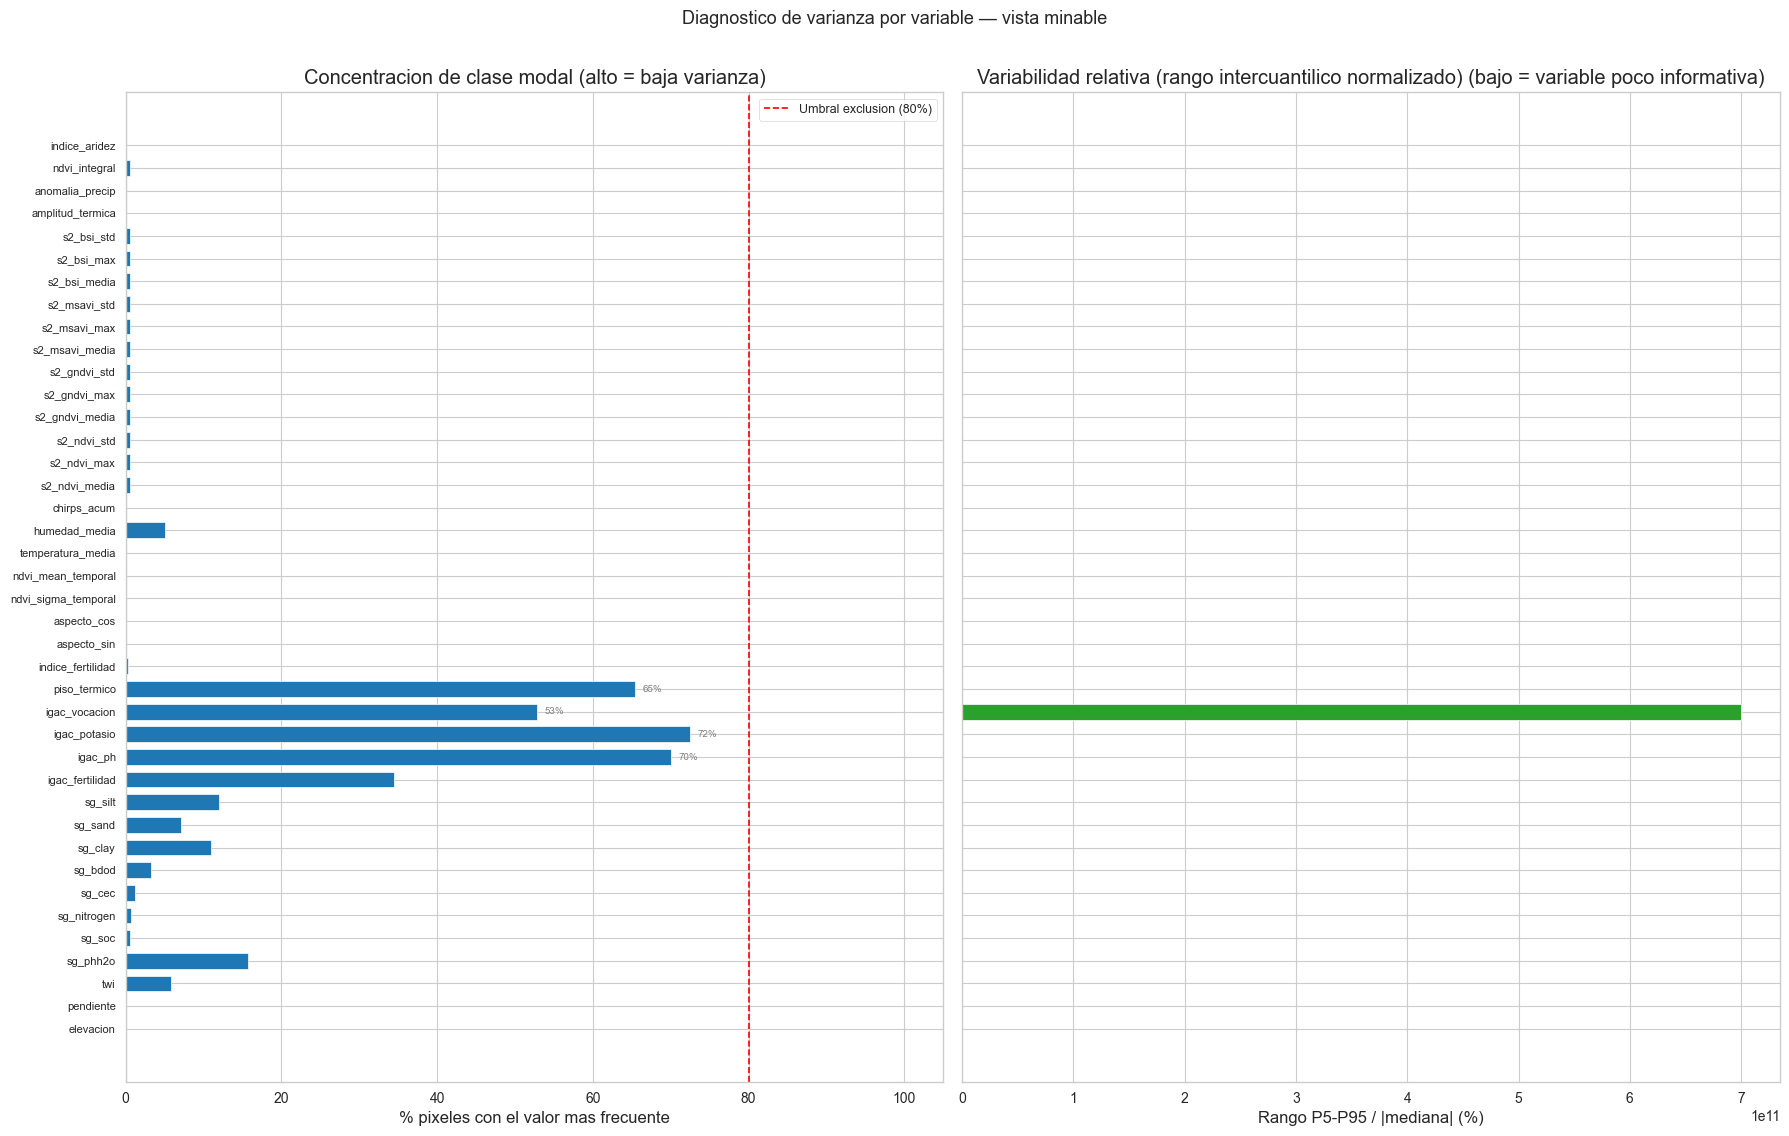

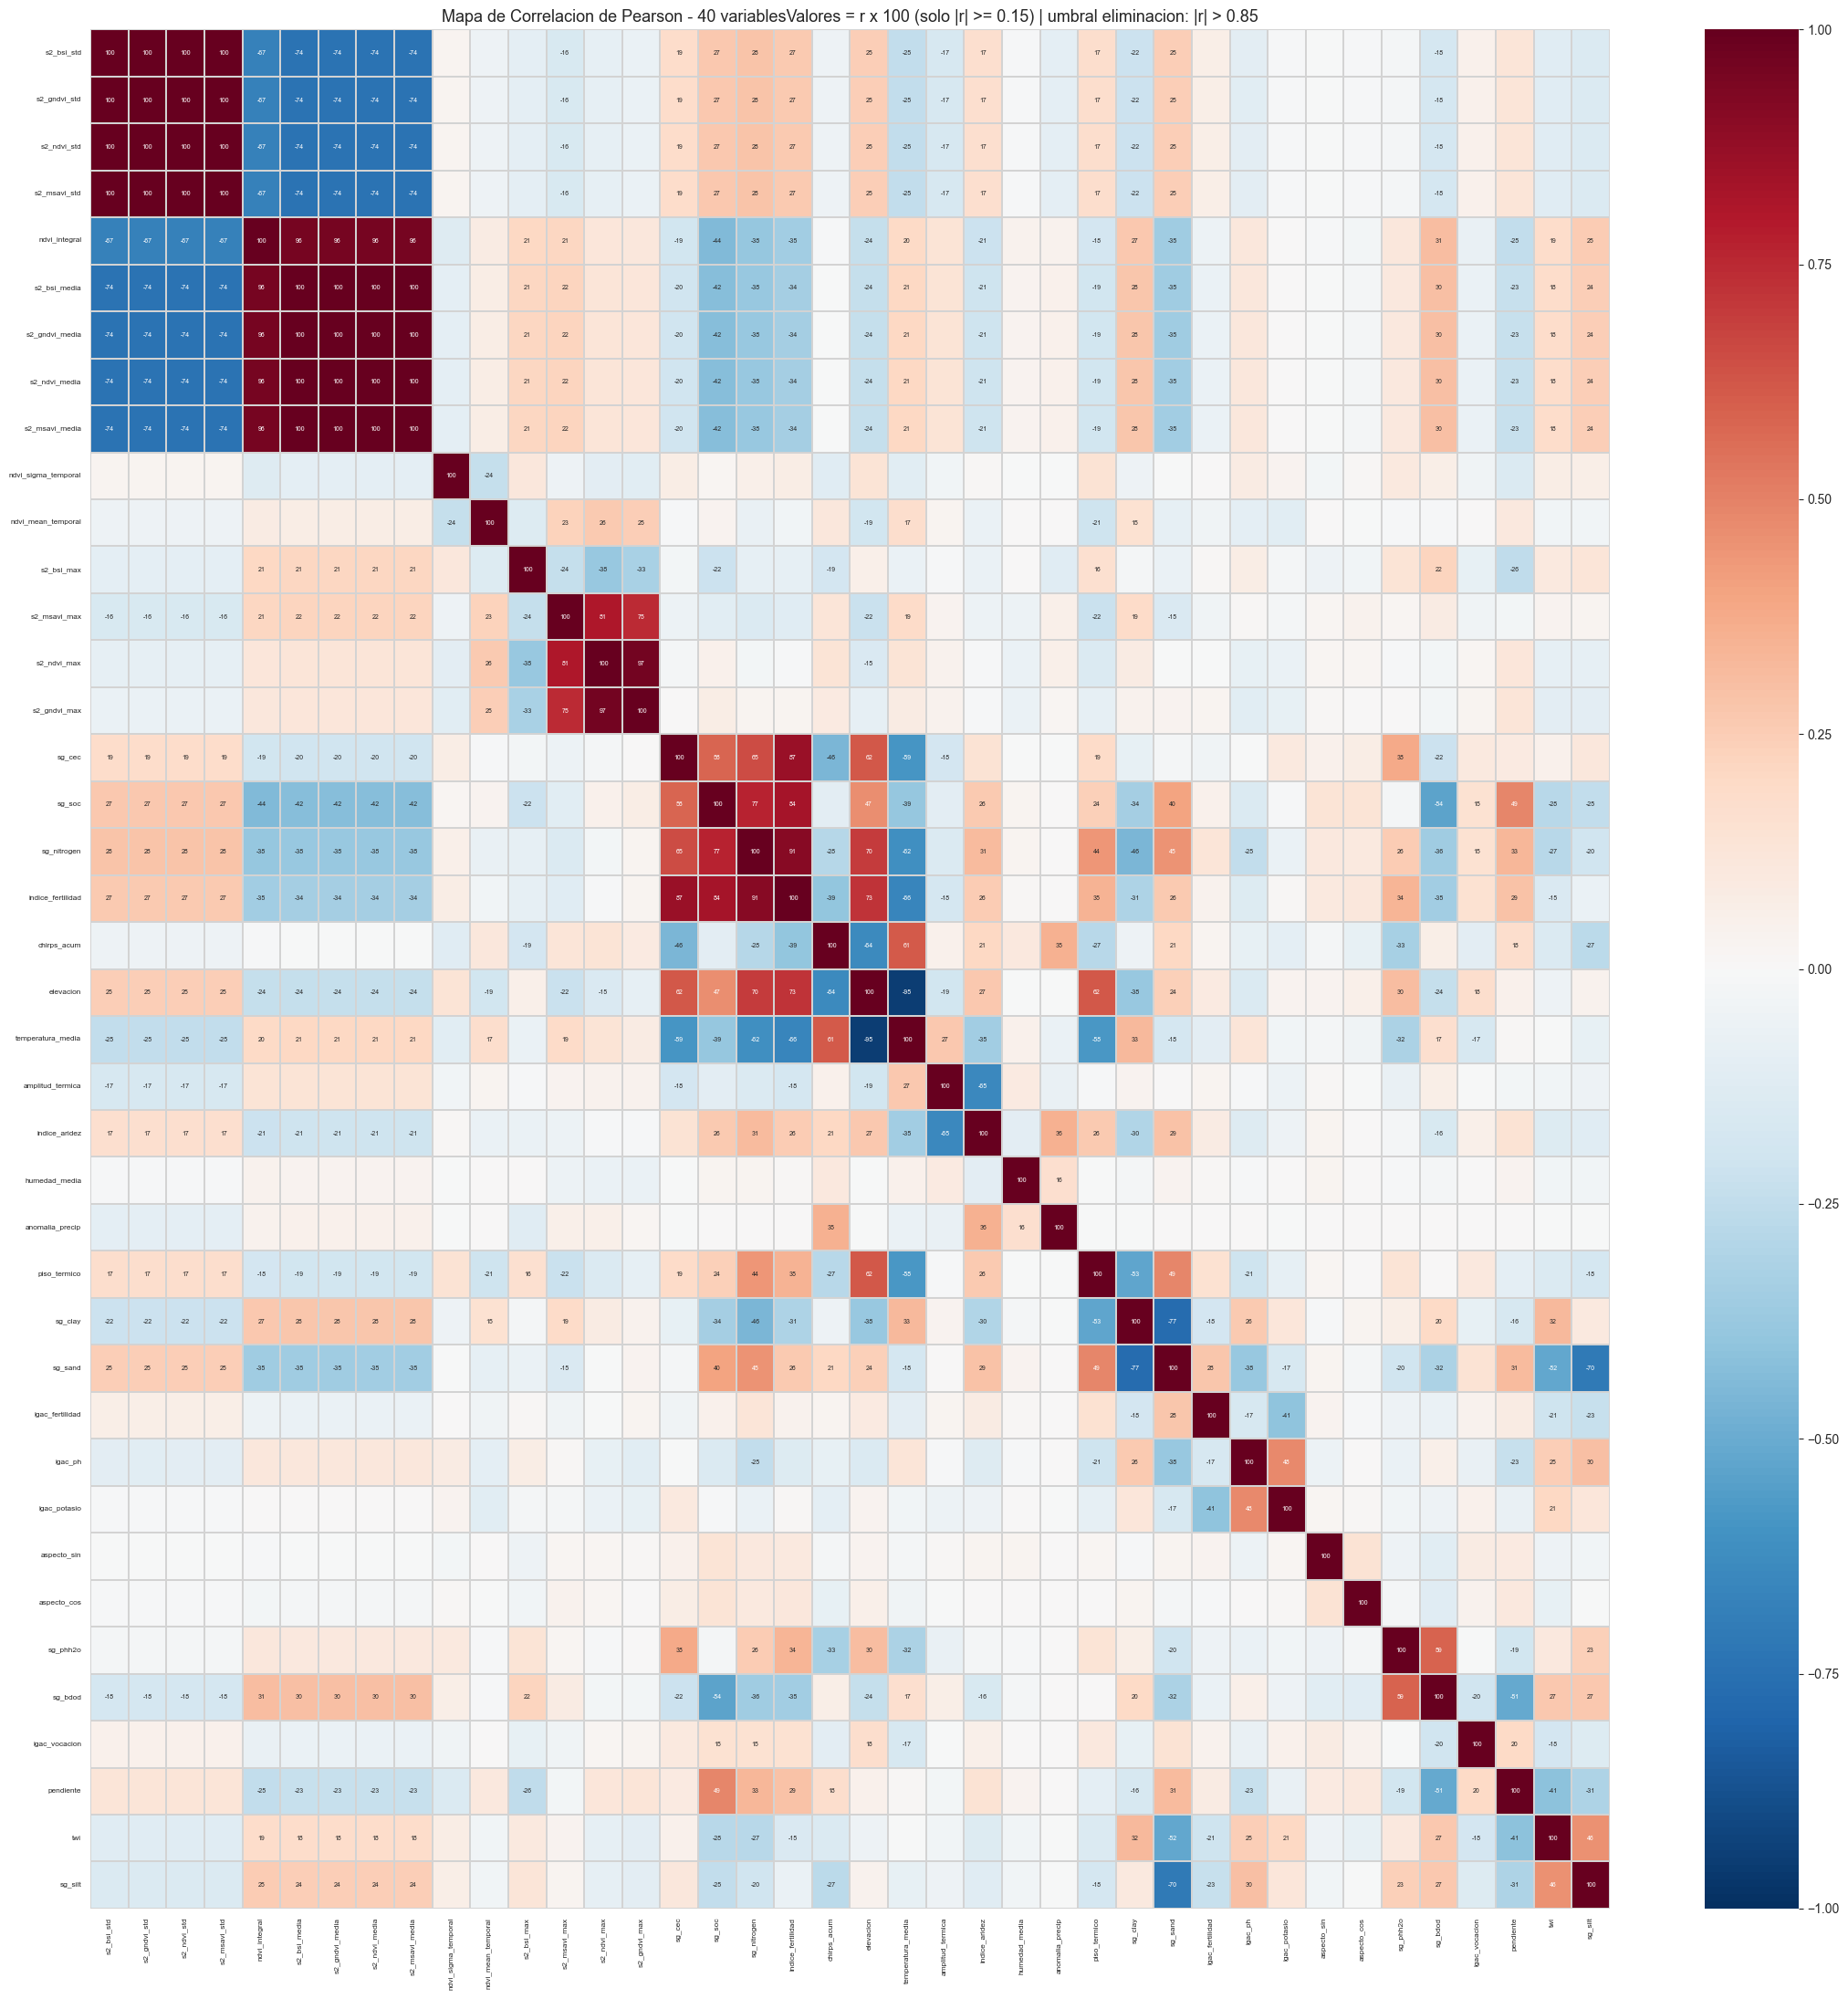


Pares con |r| > 0.85: 20
Variable A                   Variable B                         r
-----------------------------------------------------------------
  s2_ndvi_std                s2_msavi_std                +1.000
  s2_ndvi_media              s2_msavi_media              +1.000
  s2_gndvi_media             s2_msavi_media              +1.000
  s2_ndvi_media              s2_gndvi_media              +1.000
  s2_ndvi_std                s2_gndvi_std                +1.000
  s2_gndvi_std               s2_msavi_std                +1.000
  s2_gndvi_media             s2_bsi_media                +1.000
  s2_msavi_media             s2_bsi_media                +1.000
  s2_ndvi_media              s2_bsi_media                +1.000
  s2_gndvi_std               s2_bsi_std                  +1.000
  s2_ndvi_std                s2_bsi_std                  +1.000
  s2_msavi_std               s2_bsi_std                  +1.000
  s2_ndvi_max                s2_gndvi_max                +0.966
  s2_ndvi_

In [15]:
# === feature_cols: seleccion, varianza y correlacion ===
# Este es el UNICO lugar donde se define y refina feature_cols.
# Flujo en tres pasos:
#   1. Definicion inicial: todas las columnas de df_l2 no incluidas en EXCLUDE_COLS
#   2. Filtro de varianza: elimina variables cuasi-constantes (clase modal > umbral)
#   3. Filtro de correlacion: elimina variables redundantes (|r| > CORR_THRESH)
# Al final de esta celda, feature_cols es la lista definitiva para el modelo.

# --- Paso 1: definicion inicial de feature_cols ---
feature_cols = [c for c in df_l2.columns if c not in EXCLUDE_COLS]
print(f"Features iniciales ({len(feature_cols)}) — antes de filtros:")
for c in feature_cols:
    print(f"  {c}")
print()
# Objetivo: identificar y eliminar variables con correlacion de Pearson
# |r| > CORR_THRESH para reducir redundancia antes del entrenamiento.
#
# Estrategia de eliminacion:
#   Para cada par (A, B) con |corr| > umbral, se elimina la variable
#   con MAYOR correlacion media con el resto del conjunto (mas conectada
#   => mas redundante). Si empatan, se elimina la ultima en orden alfabetico.
#
# El resultado actualiza EXCLUDE_COLS y feature_cols para todas las
# celdas siguientes (scaler, entrenamiento, evaluacion).

CORR_THRESH   = 0.85   # umbral de correlacion de Pearson
SAMPLE_CORR   = 80_000 # filas para calcular la correlacion (velocidad)

# Muestra estratificada por municipio para que la correlacion no este
# sesgada hacia municipios grandes
rng_corr = np.random.default_rng(42)
n_sample = min(SAMPLE_CORR, len(df_l2))
idx_sample = rng_corr.choice(len(df_l2), n_sample, replace=False)
df_sample = df_l2.iloc[idx_sample][feature_cols].copy()

# Imputar NaN con la mediana antes de calcular correlacion
for col in df_sample.columns:
    if df_sample[col].isna().any():
        df_sample[col] = df_sample[col].fillna(df_sample[col].median())

# Filtro de varianza minima: excluir variables cuasi-constantes antes de correlacion.
# Variables con >80% de pixeles en un mismo valor tienen varianza casi nula,
# lo que fuerza r -> 0 con todo (artefacto estadistico, no informacion real).
# Casos criticos: igac_fosforo (96% clase 1), igac_ph (73%), igac_potasio (73%).
MIN_VARIANCE_PCT = 0.80   # si la clase modal supera este %, la variable se descarta
vars_cuasi_constantes = []
for col in df_sample.columns:
    top_freq = df_sample[col].value_counts(normalize=True).iloc[0]
    if top_freq > MIN_VARIANCE_PCT:
        vars_cuasi_constantes.append(col)

if vars_cuasi_constantes:
    print(f'Variables excluidas por varianza casi nula (clase modal > {MIN_VARIANCE_PCT*100:.0f}%):')
    for v in vars_cuasi_constantes:
        top_freq = df_sample[v].value_counts(normalize=True).iloc[0]
        print(f'  {v:<30} (clase modal = {top_freq*100:.1f}%)')
    EXCLUDE_COLS = list(set(EXCLUDE_COLS) | set(vars_cuasi_constantes))
    feature_cols  = [c for c in feature_cols if c not in vars_cuasi_constantes]
    df_sample = df_sample.drop(columns=vars_cuasi_constantes)

print(f'Calculando correlacion sobre {n_sample:,} filas x {len(df_sample.columns)} variables...')
corr_matrix = df_sample.corr(method='pearson')

# --- Visualizacion: distribucion de varianza por variable ---
# Dos metricas complementarias para detectar variables problematicas:
#   1. % de la clase modal (variables categoricas/ordinales): si >80%, varianza
#      casi nula y r de Pearson -> 0 con todo (artefacto, no informacion real).
#   2. Coeficiente de variacion CV = std/|mean| (variables continuas): permite
#      comparar la dispersion relativa entre variables de escalas distintas.
fig_var, axes_var = plt.subplots(1, 2, figsize=(18, max(6, len(df_sample.columns) * 0.28)))

cols_sorted = df_sample.columns.tolist()

# Panel izquierdo: % clase modal (detecta cuasi-constantes)
modal_pct = [df_sample[c].value_counts(normalize=True).iloc[0] * 100 for c in cols_sorted]
colors_modal = ['#d62728' if p > MIN_VARIANCE_PCT * 100 else '#1f77b4' for p in modal_pct]
axes_var[0].barh(cols_sorted, modal_pct, color=colors_modal, edgecolor='white', height=0.7)
axes_var[0].axvline(MIN_VARIANCE_PCT * 100, color='red', linestyle='--', linewidth=1.2,
                    label=f'Umbral exclusion ({MIN_VARIANCE_PCT*100:.0f}%)')
axes_var[0].set_xlabel('% pixeles con el valor mas frecuente')
axes_var[0].set_title('Concentracion de clase modal (alto = baja varianza)')
axes_var[0].legend(fontsize=9)
axes_var[0].set_xlim(0, 105)
axes_var[0].tick_params(axis='y', labelsize=8)
for i, (p, c) in enumerate(zip(modal_pct, colors_modal)):
    if p > 50:
        axes_var[0].text(p + 1, i, f'{p:.0f}%', va='center', fontsize=7,
                         color='#d62728' if p > MIN_VARIANCE_PCT * 100 else 'gray')

# Panel derecho: coeficiente de variacion CV = std / |mean|
# Usar percentil 5-95 para robustez ante outliers
cv_vals = []
for c in cols_sorted:
    s = df_sample[c]
    p5, p95 = s.quantile(0.05), s.quantile(0.95)
    rango_iqr = p95 - p5
    median_abs = abs(s.median()) + 1e-9
    cv_vals.append(rango_iqr / median_abs * 100)

axes_var[1].barh(cols_sorted, cv_vals, color='#2ca02c', edgecolor='white', height=0.7)
axes_var[1].set_xlabel('Rango P5-P95 / |mediana| (%)')
axes_var[1].set_title('Variabilidad relativa (rango intercuantilico normalizado) (bajo = variable poco informativa)')
axes_var[1].tick_params(axis='y', labelsize=8)
axes_var[1].set_yticklabels([])  # ya se ven en el panel izquierdo

fig_var.suptitle('Diagnostico de varianza por variable — vista minable', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print()

# --- Visualizacion: heatmap con clustering jerarquico ---
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

# Reordenar columnas por clustering
dist = 1 - corr_matrix.abs()
dist = np.clip(dist, 0, None)  # evitar valores negativos por precision
linkage = sch.linkage(squareform(dist), method='ward')
order   = sch.leaves_list(linkage)
cols_ord = corr_matrix.columns[order].tolist()
corr_ord = corr_matrix.loc[cols_ord, cols_ord]

n_feat = len(cols_ord)
# Tamanio: ajustar segun cantidad de variables para que quepan las anotaciones
fs = max(18, n_feat * 0.55)
fig, ax = plt.subplots(figsize=(fs, fs))

# Anotaciones: r expresado como porcentaje entero (87 en vez de 0.87).
# Se suprime el texto en celdas con |r| < 0.15 para no saturar el grafico.
annot_data = (corr_ord * 100).round(0).astype(int).astype(str)
annot_data[corr_ord.abs() < 0.15] = ''

annot_fontsize = max(5, int(180 / n_feat))
label_fontsize = max(6, int(200 / n_feat))

sns.heatmap(
    corr_ord, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=annot_data, fmt='',           # fmt='' porque annot ya es string formateado
    annot_kws={'size': annot_fontsize, 'weight': 'normal'},
    linewidths=0.2, linecolor='lightgray',
    xticklabels=True, yticklabels=True
)
ax.set_title(f'Mapa de Correlacion de Pearson - {n_feat} variables'
    f'Valores = r x 100 (solo |r| >= 0.15) | umbral eliminacion: |r| > {CORR_THRESH}',
    fontsize=13
)
ax.tick_params(axis='x', rotation=90, labelsize=label_fontsize)
ax.tick_params(axis='y', rotation=0,  labelsize=label_fontsize)
plt.tight_layout()
plt.show()

# --- Detectar pares altamente correlacionados ---
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'var_a', 'level_1': 'var_b', 0: 'corr'})
    .assign(abs_corr=lambda d: d['corr'].abs())
    .query('abs_corr > @CORR_THRESH')
    .sort_values('abs_corr', ascending=False)
)

print(f'\nPares con |r| > {CORR_THRESH}: {len(high_corr_pairs)}')
if len(high_corr_pairs):
    print(f'{"Variable A":<28} {"Variable B":<28} {"r":>7}')
    print('-' * 65)
    for _, row_p in high_corr_pairs.iterrows():
        print(f'  {row_p.var_a:<26} {row_p.var_b:<26} {row_p["corr"]:>+7.3f}')

# --- Seleccionar variables a eliminar ---
# Para cada par de alta correlacion, eliminar la variable con mayor
# correlacion media con el resto (mas redundante globalmente).
vars_eliminar = set()
mean_corr = corr_matrix.abs().mean()  # correlacion media con todas las variables

for _, row_p in high_corr_pairs.iterrows():
    a, b = row_p.var_a, row_p.var_b
    if a in vars_eliminar or b in vars_eliminar:
        continue  # ya eliminada en un par anterior
    # Eliminar la mas conectada (mayor correlacion media)
    eliminar = a if mean_corr[a] >= mean_corr[b] else b
    vars_eliminar.add(eliminar)

# --- Actualizar EXCLUDE_COLS y feature_cols ---
EXCLUDE_COLS = list(set(EXCLUDE_COLS) | vars_eliminar)
feature_cols_orig = feature_cols[:]
feature_cols = [c for c in feature_cols if c not in vars_eliminar]

print(f'\nVariables eliminadas por alta colinealidad ({len(vars_eliminar)}):')
for v in sorted(vars_eliminar):
    partners = high_corr_pairs[
        (high_corr_pairs.var_a == v) | (high_corr_pairs.var_b == v)
    ]
    max_r = partners['abs_corr'].max()
    print(f'  {v:<30}  (max |r| = {max_r:.3f})')

print(f'\nFeatures restantes: {len(feature_cols_orig)} -> {len(feature_cols)}')
print('Variables conservadas:')
for c in feature_cols: print(f'  {c}')


In [16]:
# === Mascara agricola: excluir pixeles claramente no-agricolas ===
#
# Problema: df_l2 incluye TODO el area de Cundinamarca que no es L1 ni L3.
# Eso incluye bosque, pasturas extensivas y otros usos no agricolas.
# EVA solo reporta hectareas cultivadas => el prior w_mun se aplica a
# un area mucho mayor que la cultivada real.
#
# Solucion (paper La Rosa et al. 2022, Scenario SII):
# Excluir pixeles sin variabilidad temporal en NDVI antes de formar los bags.
# Los dos criterios usan columnas calculadas en 04_construir_vista_minable.py
# (PASO 3e) sobre TODOS los semestres del raster, no solo el muestreado:
#
#  ndvi_sigma_temporal: std de s2_ndvi_max entre semestres por pixel.
#    Alta  => ciclo de cultivo detectable (crecimiento/cosecha alternados).
#    Baja  => vegetacion permanente y estable (bosque) o suelo fijo.
#
#  ndvi_mean_temporal: media de s2_ndvi_max entre semestres por pixel.
#    Alta  => vegetacion densa continua (bosque si sigma es bajo).
#    Baja  => suelo o vegetacion escasa (ya cubierto por L3 principalmente).
#
# ---------------------------------------------------------------
# Filtro 1 | ndvi_mean < 0.15
#   Excluye: suelo desnudo, agua, urbano sin vegetacion.
#   Remanente del L3 que quedo con fuente='eva_municipal' tras el etiquetado.
#   NO afecta: ningun cultivo (NDVI minimo en cosecha es ~0.2-0.3).
#   Queda: toda la vegetacion (agricola + bosque + pastura).
#
# Filtro 2 | ndvi_mean > 0.80 AND ndvi_sigma < 0.06
#   Excluye: bosque primario y secundario denso.
#   Logica: vegetacion alta y estable sin ciclo detectado = bosque andino.
#   Umbral conservador: Cafe tiene mean ~0.60-0.72, sigma ~0.07-0.12.
#   Palma y Cacao tienen mean alto pero sigma > 0.06 por rotacion y lluvia.
#   NO afecta: ningun cultivo permanente ni transitorio representativo.
#   Queda: zona agricola potencial + pastura con variacion.
#
# Filtro 3 | ndvi_mean > 0.55 AND ndvi_sigma < 0.04
#   Excluye: bosque secundario y pastura permanente densa sin variacion.
#   Pasturas extensivas de Cundinamarca (kikuyo, braquiaria) tienen NDVI
#   moderado y muy estable (no se cosechan, no rotan).
#   Umbral mas estricto de sigma (0.04) para no afectar Cafe (sigma ~0.07+).
#   Queda: pixeles con alguna senial de uso agricola dinamico.
# ---------------------------------------------------------------

SIGMA_COL = 'ndvi_sigma_temporal'
MEAN_COL  = 'ndvi_mean_temporal'

if SIGMA_COL not in df_l2.columns or MEAN_COL not in df_l2.columns:
    print('ADVERTENCIA: columnas de mascara agricola no encontradas en el parquet.')
    print('Regenerar la vista minable con 04_construir_vista_minable.py para incluirlas.')
    print('Se omite el filtro agricola y se continua con todos los pixeles L2.')
    mask_agricola = pd.Series(True, index=df_l2.index)
else:
    n0 = len(df_l2)
    sigma = df_l2[SIGMA_COL]
    mean  = df_l2[MEAN_COL]

    # Filtro 1: sin vegetacion
    f1 = ~(mean < 0.15)
    n_f1 = n0 - f1.sum()

    # Filtro 2: bosque denso primario (alta media, muy estable)
    f2 = ~((mean > 0.80) & (sigma.fillna(1) < 0.06))
    n_f2 = (~f2 & f1).sum()

    # Filtro 3: bosque secundario / pastura permanente (media moderada-alta, sin variacion)
    f3 = ~((mean > 0.55) & (sigma.fillna(1) < 0.04))
    n_f3 = (~f3 & f1 & f2).sum()

    mask_agricola = f1 & f2 & f3

    print('Mascara agricola (pixeles L2):')
    print(f'  Total inicial:                          {n0:>10,}')
    print(f'  Filtro 1 (mean < 0.15, sin veg):       -{n_f1:>9,}  ({100*n_f1/n0:.1f}%)')
    print(f'  Filtro 2 (bosque denso primario):       -{n_f2:>9,}  ({100*n_f2/n0:.1f}%)')
    print(f'  Filtro 3 (bosque sec / pastura estable):-{n_f3:>9,}  ({100*n_f3/n0:.1f}%)')
    print(f'  Quedan (zona agricola potencial):        {mask_agricola.sum():>10,}  ({100*mask_agricola.mean():.1f}%)')
    print()

    # Aplicar mascara
    idx_keep = np.where(mask_agricola.values)[0]
    df_l2  = df_l2.iloc[idx_keep].reset_index(drop=True)
    W_norm = W_norm[idx_keep]          # proporciones EVA alineadas

    print(f'  df_l2 tras mascara: {len(df_l2):,} filas')
    print(f'  W_norm tras mascara: {W_norm.shape}')
    print(f'  Municipios restantes: {df_l2["cod_mun"].nunique()}')
    print(f'  Semestres restantes:  {df_l2["semestre"].nunique()}')


Mascara agricola (pixeles L2):
  Total inicial:                           3,564,346
  Filtro 1 (mean < 0.15, sin veg):       -   11,229  (0.3%)
  Filtro 2 (bosque denso primario):       -  350,268  (9.8%)
  Filtro 3 (bosque sec / pastura estable):-  390,389  (11.0%)
  Quedan (zona agricola potencial):         2,812,460  (78.9%)

  df_l2 tras mascara: 2,812,460 filas
  W_norm tras mascara: (2812460, 18)
  Municipios restantes: 113
  Semestres restantes:  9


In [17]:
# === Split estratificado train/valid/test por municipio ===
# Estrategia: agrupar municipios por cultivo dominante -> samplear 70/15/15.
# Post-procesamiento: clases prioritarias ausentes en train se rescatan
# moviendo el municipio con mayor proporcion de esa clase desde valid/test.

import math
from collections import defaultdict

TRAIN_FRAC = 0.70
VALID_FRAC = 0.15
TEST_FRAC  = 0.15
SEED_SPLIT = 42

# Clases que DEBEN aparecer en train aunque sean minoritarias
CLASES_PRIORITARIAS = ["Papa", "Palma", "Platano", "Banano", "Tomate_Arbol"]
# Proporcion minima de la clase en algun mun de train para considerarla cubierta
UMBRAL_COBERTURA = 0.05

# --- W_norm medio y cultivo dominante por municipio ---
mun_series = df_l2["cod_mun"].astype(int)
muns_all = np.sort(mun_series.unique())

mun_to_dom = {}
mun_to_w   = {}
for mun in muns_all:
    mask = mun_series.values == mun
    w_mean = W_norm[mask].mean(axis=0)
    mun_to_dom[mun] = int(w_mean.argmax())
    mun_to_w[mun]   = w_mean

# Agrupar municipios por cultivo dominante
# Clases con < MIN_MUN municipios se fusionan en grupo "Minoritario"
MIN_MUN = 4
strat_groups = defaultdict(list)
for mun, dom in mun_to_dom.items():
    strat_groups[dom].append(mun)

minority_pool = []
main_groups = {}
for dom, muns in strat_groups.items():
    if len(muns) < MIN_MUN:
        minority_pool.extend(muns)
    else:
        main_groups[dom] = muns
if minority_pool:
    main_groups[-1] = minority_pool  # -1 = grupo Minoritario

rng = np.random.default_rng(SEED_SPLIT)
muns_train, muns_valid, muns_test = [], [], []

for dom, muns in main_groups.items():
    arr = rng.permutation(muns)
    n = len(arr)
    n_te = max(1, math.floor(n * TEST_FRAC))
    n_va = max(1, math.floor(n * VALID_FRAC))
    n_va = min(n_va, n - n_te - 1)  # al menos 1 en train
    muns_test.extend(arr[:n_te].tolist())
    muns_valid.extend(arr[n_te:n_te + n_va].tolist())
    muns_train.extend(arr[n_te + n_va:].tolist())

muns_train = set(muns_train)
muns_valid = set(muns_valid)
muns_test  = set(muns_test)

# === Garantia de cobertura para clases prioritarias ===
# Si max(W_train[cls]) < UMBRAL_COBERTURA, se mueve el mejor municipio
# candidato desde valid o test a train.
print("Verificacion de cobertura de clases prioritarias:")
for cls_name in CLASES_PRIORITARIAS:
    cls_idx = catalogo[cls_name]
    max_w_train = max((mun_to_w[m][cls_idx] for m in muns_train), default=0.0)
    if max_w_train >= UMBRAL_COBERTURA:
        print(f"  {cls_name}: OK  (max W_train={max_w_train:.3f})")
        continue
    candidatos = sorted(
        [(mun_to_w[m][cls_idx], m, "valid") for m in muns_valid] +
        [(mun_to_w[m][cls_idx], m, "test")  for m in muns_test],
        reverse=True
    )
    if not candidatos or candidatos[0][0] == 0.0:
        print(f"  {cls_name}: SIN DATOS en ningun municipio (clase ausente del dataset)")
        continue
    w_best, mun_best, src = candidatos[0]
    muns_train.add(mun_best)
    if src == "valid":
        muns_valid.discard(mun_best)
    else:
        muns_test.discard(mun_best)
    print(f"  {cls_name}: RESCATE municipio {mun_best} de {src} -> train  (W={w_best:.3f})")
print()

# Verificacion de integridad del split
assert len(muns_train & muns_valid) == 0
assert len(muns_train & muns_test) == 0
assert len(muns_valid & muns_test) == 0
assert muns_train | muns_valid | muns_test == set(muns_all.tolist())

# Indices de pixeles por split
mun_arr = mun_series.values
idx_train = np.where(np.isin(mun_arr, list(muns_train)))[0]
idx_valid = np.where(np.isin(mun_arr, list(muns_valid)))[0]
idx_test  = np.where(np.isin(mun_arr, list(muns_test)))[0]

print(f"Train: {len(idx_train):,} pixeles ({len(muns_train)} municipios)")
print(f"Valid: {len(idx_valid):,} pixeles ({len(muns_valid)} municipios)")
print(f"Test:  {len(idx_test):,} pixeles ({len(muns_test)} municipios)")
print()

# Clases representadas por split (pseudo-GT argmax W_norm)
for split_name, idx_s in [("Train", idx_train), ("Valid", idx_valid), ("Test", idx_test)]:
    y_s = W_norm[idx_s].argmax(axis=1)
    clases_s = sorted(set(y_s.tolist()))
    print(f"{split_name}: {len(clases_s)} clases representadas -> "
          + ", ".join(inv_catalogo[c] for c in clases_s))

Verificacion de cobertura de clases prioritarias:
  Papa: OK  (max W_train=1.000)
  Palma: OK  (max W_train=0.869)
  Platano: OK  (max W_train=0.324)
  Banano: OK  (max W_train=0.525)
  Tomate_Arbol: OK  (max W_train=0.398)

Train: 1,876,361 pixeles (81 municipios)
Valid: 420,138 pixeles (16 municipios)
Test:  515,961 pixeles (16 municipios)

Train: 15 clases representadas -> Cana_Panelera, Cafe, Maiz, Mango, Frijol, Cacao, Arveja, Palma, Banano, Citricos, Mora, Yuca, Habichuela, Hortalizas, Papa
Valid: 9 clases representadas -> Cana_Panelera, Cafe, Maiz, Mango, Frijol, Citricos, Tomate_Arbol, Hortalizas, Papa
Test: 9 clases representadas -> Cana_Panelera, Cafe, Maiz, Platano, Mango, Frijol, Cacao, Hortalizas, Papa


In [18]:
# === Preprocesador (StandardScaler para todas las features numericas) ===
#X_full = df_l2[feature_cols].values
X_full = df_l2[feature_cols].values.copy()
y_full = df_l2['cultivo_id_final'].values
W_full = W_norm  # (N, 11) ya renormalizado

# Sustituir NaN por la mediana de cada columna (sklearn no acepta NaN en muchos casos)
for j, c in enumerate(feature_cols):
    col = X_full[:, j]
    if np.isnan(col).any():
        med = np.nanmedian(col)
        X_full[np.isnan(col), j] = med

scaler = StandardScaler()
X_train = scaler.fit_transform(X_full[idx_train])
X_valid = scaler.transform(X_full[idx_valid])
X_test  = scaler.transform(X_full[idx_test])

y_train = y_full[idx_train]
y_valid = y_full[idx_valid]
y_test  = y_full[idx_test]

W_train = W_full[idx_train]
W_valid = W_full[idx_valid]
W_test  = W_full[idx_test]

# Bag ids (cod_mun + semestre concatenados como string)
bag_train = df_l2.iloc[idx_train]['_bag_id'].values
bag_valid = df_l2.iloc[idx_valid]['_bag_id'].values
bag_test  = df_l2.iloc[idx_test]['_bag_id'].values

print(f"X_train: {X_train.shape}  W_train: {W_train.shape}  bags_train: {len(set(bag_train))}")
print(f"X_valid: {X_valid.shape}  W_valid: {W_valid.shape}  bags_valid: {len(set(bag_valid))}")
print(f"X_test:  {X_test.shape}   W_test:  {W_test.shape}   bags_test:  {len(set(bag_test))}")


X_train: (1876361, 29)  W_train: (1876361, 18)  bags_train: 81
X_valid: (420138, 29)  W_valid: (420138, 18)  bags_valid: 16
X_test:  (515961, 29)   W_test:  (515961, 18)   bags_test:  16


---
## 4. Modelo L2 LLP-Co (PyTorch + Sinkhorn-Knopp)

Implementación adaptada del Algoritmo 1 del paper (La Rosa et al. 2022).

**Componentes:**
- `MLPEncoder`: 4 capas (256→128→64→512) con LayerNorm/GELU/Dropout, salida normalizada L2.
- `Prototypes`: **K=18** vectores entrenables en ℝ^{512} (uno por clase L2).
- `FeatureAugmenter`: dropout + ruido gaussiano (hiperparámetros optimizados via Optuna) → 2 vistas por pixel.
- `sinkhorn_knopp`: solver OT con regularización entrópica, 5 iteraciones (ε optimizado: 0.093).
- `swap_loss`: pérdida cruzada intercambiada entre vistas (eq. 7-9 del paper).

**Bag size:** BAG_SIZE=2048 píxeles muestreados aleatoriamente por municipio por epoch.


In [19]:
# === Modulos de PyTorch ===

class MLPEncoder(nn.Module):
    """Encoder tabular: features -> embedding 1024 normalizado L2."""
    def __init__(self, n_features, hidden_dims=(256, 128, 64), emb_dim=1024, dropout=0.2):
        super().__init__()
        layers = []
        in_dim = n_features
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            in_dim = h
        layers += [nn.Linear(in_dim, emb_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        z = self.net(x)
        z = F.normalize(z, dim=-1)  # esfera unitaria
        return z


class Prototypes(nn.Module):
    """K prototipos entrenables en ℝ^{emb_dim}."""
    def __init__(self, K, emb_dim=1024):
        super().__init__()
        # Init ortogonal: maxima separacion inicial entre prototipos (QR decomp)
        W = torch.randn(emb_dim, K)
        Q, _ = torch.linalg.qr(W)          # columnas ortogonales
        self.V = nn.Parameter(Q[:, :K].T)  # (K, emb_dim)

    def normed(self):
        return F.normalize(self.V, dim=-1)

    def forward(self, z):
        # cosine similarity: (N, emb) x (emb, K) -> (N, K)
        return z @ self.normed().T


def build_feat_groups(feature_cols):
    """
    Clasifica cada feature en un grupo semantico y retorna indices por grupo.
    Permite augmentacion diferenciada: topo/suelo no se zerean, S2 se simula
    nubosidad con dropout alto, clima con ruido moderado.
    """
    topo_kw  = ('elevacion','pendiente','twi','aspecto','piso_termico')
    suelo_kw = ('sg_','igac_','indice_fertilidad')
    clima_kw = ('temperatura_media','humedad_media','chirps','amplitud_termica',
                'anomalia_precip','indice_aridez')
    s2_kw    = ('s2_','ndvi_integral')

    groups = {'topo': [], 'suelo': [], 'clima': [], 's2': [], 'otro': []}
    for j, col in enumerate(feature_cols):
        if   any(col.startswith(k) or col == k for k in topo_kw):  groups['topo'].append(j)
        elif any(col.startswith(k) or col == k for k in suelo_kw): groups['suelo'].append(j)
        elif any(col.startswith(k) or col == k for k in clima_kw): groups['clima'].append(j)
        elif any(col.startswith(k) or col == k for k in s2_kw):    groups['s2'].append(j)
        else:                                                        groups['otro'].append(j)

    # Convertir a tensores de indices para indexado rapido en GPU
    return {g: torch.tensor(idx, dtype=torch.long) for g, idx in groups.items() if idx}


def augment_features_v2(X, feat_groups, p_drop=0.2, sigma=0.05):
    """
    Augmentacion diferenciada por grupo semantico:
      topo / suelo : sin dropout, ruido muy bajo (datos estaticos/cuasi-estaticos)
      clima        : dropout bajo (0.10), ruido moderado
      s2           : dropout alto (p_drop, simula nubosidad), ruido moderado
      otro         : dropout moderado, ruido bajo
    """
    X_aug = X.clone()
    dev   = X.device
    n     = X.shape[0]

    for grp, idx in feat_groups.items():
        idx = idx.to(dev)
        col = X_aug[:, idx]  # (n, n_feat_grupo)

        if grp in ('topo', 'suelo'):
            # Estaticos: solo ruido gaussiano muy bajo, nunca dropout
            X_aug[:, idx] = col + torch.randn_like(col) * (sigma * 0.2)

        elif grp == 'clima':
            # Climaticos: dropout bajo (10%) + ruido moderado
            mask = (torch.rand(n, len(idx), device=dev) > 0.10).float()
            X_aug[:, idx] = col * mask + torch.randn_like(col) * sigma

        elif grp == 's2':
            # Sentinel-2: dropout alto (simula cobertura de nubes) + ruido
            mask = (torch.rand(n, len(idx), device=dev) > p_drop).float()
            X_aug[:, idx] = col * mask + torch.randn_like(col) * sigma

        else:
            # Resto: dropout moderado + ruido bajo
            mask = (torch.rand(n, len(idx), device=dev) > (p_drop * 0.5)).float()
            X_aug[:, idx] = col * mask + torch.randn_like(col) * (sigma * 0.5)

    return X_aug


# Construir grupos usando feature_cols definido en la celda anterior
feat_groups = build_feat_groups(feature_cols)
print('Grupos de features para augmentacion:')
for g, idx in feat_groups.items():
    names = [feature_cols[i] for i in idx.tolist()]
    print(f'  {g:<6} ({len(names):2d} features): {names}')


#@torch.no_grad()
#def sinkhorn_knopp(scores, w, n_iter=5, eps=0.05):
#    """
#    scores: (n, K) similitudes de prototipos
#    w:      (K,)  proporciones del bag (suma 1)
#    Devuelve Q (n, K) con filas que suman 1 y columnas con masa proporcional a w*n.
#    """
#    n, K = scores.shape
#    Q = torch.exp(scores / eps).clamp(min=1e-8)  # (n, K)
#    target_col = (w * n).clamp(min=1e-8)         # (K,)
#    target_row = torch.ones(n, device=Q.device)  # (n,)#

#    for _ in range(n_iter):
#        # Normalizar columnas
#        Q = Q * (target_col.unsqueeze(0) / Q.sum(dim=0, keepdim=True).clamp(min=1e-8))
#        # Normalizar filas
#        Q = Q * (target_row.unsqueeze(1) / Q.sum(dim=1, keepdim=True).clamp(min=1e-8))
#    return Q

@torch.no_grad()
def sinkhorn_knopp(scores, w, n_iter=5, eps=0.01):
    """Transporte Óptimo con truco de estabilidad numérica (resta el max)."""
    n, K = scores.shape
    scores = scores - scores.max(dim=1, keepdim=True).values  # <-- TRUCO VITAL
    Q = torch.exp(scores / eps).clamp(min=1e-8)  
    target_col = (w * n).clamp(min=1e-8)         
    target_row = torch.ones(n, device=Q.device)  

    for _ in range(n_iter):
        Q = Q * (target_col.unsqueeze(0) / Q.sum(dim=0, keepdim=True).clamp(min=1e-8))
        Q = Q * (target_row.unsqueeze(1) / Q.sum(dim=1, keepdim=True).clamp(min=1e-8))
    return Q


def weighted_swap_loss(p_s, p_t, q_s, q_t, w_b):
    """
    Swap loss ponderada por frecuencia inversa de clase en el bag.
    Clases raras (w_b pequeno) reciben mayor peso -> reduce colapso de prototipos.
    w_b: (K,) proporciones EVA del municipio, suma=1.
    """
    # Peso inversamente proporcional a la frecuencia de cada clase
    class_w = 1.0 / (w_b + 1e-3)                     # (K,) — raro = peso alto
    class_w = class_w / class_w.sum() * K             # normalizar: media=1

    loss_st = -(q_s * torch.log(p_t.clamp(1e-8))).sum(-1)  # (n,)
    loss_ts = -(q_t * torch.log(p_s.clamp(1e-8))).sum(-1)

    # Peso por pixel: suma ponderada de la pseudo-etiqueta con class_w
    pixel_w = (q_s * class_w.unsqueeze(0)).sum(-1)    # (n,)
    pixel_w = pixel_w / pixel_w.mean().clamp(1e-8)    # escalar a media=1

    return ((loss_st + loss_ts) * pixel_w).mean()


def koleo_loss(prototypes):
    """
    KoLeo regularization: penaliza prototipos similares entre si.
    Mantiene los K prototipos separados en la hiperesfera -> evita colapso.
    Ref: Sablayrolles et al. 2023 / DINO family.
    """
    V = prototypes.normed()                            # (K, emb) normalizado
    sim = V @ V.T                                      # (K, K) similitud coseno
    mask = 1 - torch.eye(K, device=V.device)          # off-diagonal
    return (sim * mask).pow(2).sum() / (K * (K - 1))

print("Modulos LLP-Co definidos.")


Grupos de features para augmentacion:
  topo   ( 5 features): ['pendiente', 'twi', 'piso_termico', 'aspecto_sin', 'aspecto_cos']
  suelo  (11 features): ['sg_phh2o', 'sg_soc', 'sg_cec', 'sg_bdod', 'sg_clay', 'sg_sand', 'sg_silt', 'igac_fertilidad', 'igac_ph', 'igac_potasio', 'igac_vocacion']
  clima  ( 6 features): ['temperatura_media', 'humedad_media', 'chirps_acum', 'amplitud_termica', 'anomalia_precip', 'indice_aridez']
  s2     ( 5 features): ['s2_gndvi_max', 's2_msavi_max', 's2_bsi_max', 's2_bsi_std', 'ndvi_integral']
  otro   ( 2 features): ['ndvi_sigma_temporal', 'ndvi_mean_temporal']
Modulos LLP-Co definidos.


In [20]:
# === Estructuras para bags dinamicos (LLP-Co) ===
def build_bag_index(bag_ids):
    idx_by_bag = collections.defaultdict(list)
    for i, b in enumerate(bag_ids):
        idx_by_bag[b].append(i)
    return {b: np.asarray(v, dtype=np.int64) for b, v in idx_by_bag.items()}

def compute_w_mun(W_split, bag_index):
    w_mun = {}
    for mun, idx in bag_index.items():
        w = W_split[idx].mean(axis=0)
        w_mun[mun] = (w / w.sum()).astype(np.float32)
    return w_mun

def sample_bag(idx_pool, bag_size, rng):
    """Muestrea hasta bag_size indices del pool sin reemplazo.
    Si el pool es mas chico que bag_size, devuelve todos los indices
    (nunca clona pixeles para no sesgar la distribucion del bag).
    """
    if len(idx_pool) <= bag_size:
        return idx_pool          # pool completo, sin duplicar
    return rng.choice(idx_pool, bag_size, replace=False)

def swap_loss(p_s, p_t, q_s, q_t):
    """Pérdida cruzada simplificada."""
    loss_st = -(q_s * torch.log(p_t.clamp(min=1e-8))).sum(dim=-1).mean()
    loss_ts = -(q_t * torch.log(p_s.clamp(min=1e-8))).sum(dim=-1).mean()
    return loss_st + loss_ts


bag_index_tr = build_bag_index(bag_train)
bag_index_va = build_bag_index(bag_valid)
W_mun_tr = compute_w_mun(W_train, bag_index_tr)
W_mun_va = compute_w_mun(W_valid, bag_index_va)

print(f"Bags train: {len(bag_index_tr)} municipios | bags valid: {len(bag_index_va)} municipios")
sizes_tr = [len(v) for v in bag_index_tr.values()]
print(f"Pool train: min={min(sizes_tr)}, median={int(np.median(sizes_tr))}, max={max(sizes_tr)}")
# print(f"Municipios con pool < BAG_SIZE (usaran muestreo con reemplazo): ")
# print(f"{sum(s < BAG_SIZE for s in sizes_tr)}")


Bags train: 81 municipios | bags valid: 16 municipios
Pool train: min=18, median=10350, max=142551


In [21]:
# === Configuracion de entrenamiento ===
N_FEATURES = X_train.shape[1]
K = K_FINAL         # 18 clases L2 (Citricos + Hortalizas)
EMB_DIM = 512
TAU = 0.04965
EPS_SK = 0.022429
N_SINKHORN = 5
LR_INIT = 0.001164
LR_MIN = 1e-5
WEIGHT_DECAY = 0.000000
WARMUP_EPOCHS = 5
TOTAL_EPOCHS = 500
P_DROP_AUG = 0.210573
SIGMA_AUG = 0.028360
FREEZE_PROTO_EPOCHS = 1     # prototipos congelados durante 1ra epoca
KOLEO_WEIGHT = 0.213573          # peso de KoLeo regularization (0=off)
BAG_SIZE = 2048             # pixeles muestreados por municipio por epoch (= batch size del paper)
SEED = 42
GRAD_CLIP = 1.0          # clipping de gradiente (Optuna y entrenamiento final)

print(f"Config LLP-Co: K={K}, emb={EMB_DIM}, lr={LR_INIT}->{LR_MIN}, "
      f"epocas={TOTAL_EPOCHS} (warmup={WARMUP_EPOCHS}), "
      f"sinkhorn iter={N_SINKHORN} eps={EPS_SK}, tau={TAU}")


Config LLP-Co: K=18, emb=512, lr=0.001164->1e-05, epocas=500 (warmup=5), sinkhorn iter=5 eps=0.022429, tau=0.04965


In [22]:
# === Funciones compartidas: scheduler, epoch de entrenamiento y validacion ===

def cosine_warmup_lr(epoch, n_epochs, lr_init, lr_min, warmup):
    if epoch < warmup:
        return lr_init * (epoch + 1) / warmup
    progress = (epoch - warmup) / max(n_epochs - warmup, 1)
    return lr_min + 0.5 * (lr_init - lr_min) * (1 + np.cos(np.pi * progress))

def run_train_epoch(enc, proto, opt, bag_ids, bag_index, X_t, W_mun_t,
                    tau, eps_sk, sigma, p_drop, koleo_w, feat_groups,
                    grad_clip=None, rng=None):
    """Un epoch de entrenamiento LLP-Co. Retorna loss promedio."""
    if rng is None:
        rng = np.random.RandomState()
    enc.train(); proto.train()
    loss_acc, n_bags = 0.0, 0
    for b in bag_ids:
        idx  = sample_bag(bag_index[b], BAG_SIZE, rng)
        X_b  = X_t[idx].to(DEVICE)
        w_b  = W_mun_t[b]
        X_s  = augment_features_v2(X_b, feat_groups, p_drop, sigma)
        X_t_ = augment_features_v2(X_b, feat_groups, p_drop, sigma)
        z_s  = enc(X_s);    z_t_ = enc(X_t_)
        sc_s = proto(z_s);  sc_t = proto(z_t_)
        q_s  = sinkhorn_knopp(sc_s.detach(), w_b, N_SINKHORN, eps_sk)
        q_t  = sinkhorn_knopp(sc_t.detach(), w_b, N_SINKHORN, eps_sk)
        q_s  = q_s / q_s.sum(1, keepdim=True).clamp(1e-8)
        q_t  = q_t / q_t.sum(1, keepdim=True).clamp(1e-8)
        p_s  = F.softmax(sc_s / tau, dim=-1)
        p_t_ = F.softmax(sc_t / tau, dim=-1)
        loss = weighted_swap_loss(p_s, p_t_, q_s, q_t, w_b) + koleo_w * koleo_loss(proto)
        opt.zero_grad()
        loss.backward()
        if grad_clip:
            torch.nn.utils.clip_grad_norm_(
                list(enc.parameters()) + list(proto.parameters()), grad_clip
            )
        opt.step()
        loss_acc += loss.item()
        n_bags += 1
    return loss_acc / max(n_bags, 1)

def eval_kl(enc, proto, bag_index, X_t, W_mun_t, tau):
    """KL(w_eva || p_modelo) promedio sobre bags."""
    enc.eval(); proto.eval()
    kl_acc = 0.0
    with torch.no_grad():
        for b, idx in bag_index.items():
            w_e = W_mun_t[b]
            p   = F.softmax(proto(enc(X_t[idx].to(DEVICE))) / tau, dim=-1).mean(0)
            kl_acc += (w_e * (w_e.clamp(1e-8).log() - p.clamp(1e-8).log())).sum().item()
    return kl_acc / len(bag_index)

# Tensores compartidos entre Optuna y entrenamiento final
X_train_t  = torch.from_numpy(X_train).float()
X_valid_t  = torch.from_numpy(X_valid).float()
W_mun_tr_t = {mun: torch.from_numpy(w).float().to(DEVICE) for mun, w in W_mun_tr.items()}
W_mun_va_t = {mun: torch.from_numpy(w).float().to(DEVICE) for mun, w in W_mun_va.items()}


# Indices de pixeles EVA dentro de train (excluye monitoreo UPRA).
# Usado en el check de colapso de Optuna para evitar sesgo del prototipo Papa.
_fuente_train = df_l2.iloc[idx_train]['fuente'].values
idx_eva_in_train = np.where(_fuente_train == 'eva_municipal')[0]
print(f"idx_eva_in_train: {len(idx_eva_in_train):,} pixeles EVA en train "
      f"({len(idx_eva_in_train)/len(idx_train)*100:.1f}% del total train)")

idx_eva_in_train: 1,537,317 pixeles EVA en train (81.9% del total train)


---
## 5. Optimizacion de Hiperparametros con Optuna

Busca la combinación de **7 hiperparámetros** que minimiza `KL_valid` (TPE multivariado, MedianPruner).
Cada trial entrena durante `OPTUNA_EPOCHS=80` épocas. Al final se actualizan las variables globales con los mejores parámetros (trial #562, KL_valid=**0.5184**, 100 trials en 160.9 min).

| Parámetro | Rango | Valor óptimo | Rol |
|-----------|-------|-------------|-----|
| `TAU` | 0.05 – 0.20 | 0.1279 | Temperatura softmax: bajo = predicciones nítidas |
| `EPS_SK` | 0.005 – 0.10 | 0.0930 | Regularización Sinkhorn: bajo = más fiel al prior EVA |
| `SIGMA_AUG` | 0.01 – 0.15 | 0.0326 | Intensidad de ruido gaussiano en augmentación |
| `LR_INIT` | 0.05 – 0.30 | 0.0921 | Tasa de aprendizaje inicial (AdamW) |
| `KOLEO_WEIGHT` | 0.01 – 0.50 | 0.2012 | Peso de la regularización KoLeo (diversidad de prototipos) |
| `P_DROP_AUG` | 0.05 – 0.40 | 0.2039 | Probabilidad de dropout en augmentación de features |
| `WEIGHT_DECAY` | 1e-7 – 1e-3 | 4.38e-4 | Regularización L2 del optimizador |


c:\Users\andres\anaconda3\envs\agroplus\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\andres\anaconda3\envs\agroplus\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


Estudio "llp_co_v2" | Trials completados previos: 0
Lanzando 100 trials x 80 epocas...
Params: TAU, EPS_SK, SIGMA_AUG, LR_INIT, KOLEO_WEIGHT, P_DROP_AUG, WEIGHT_DECAY
Sampler: TPE multivariado | Pruner: MedianPruner | DB: sqlite:///d:/trabajo/agroplus/modelado/optuna_llp_co_v1.db


Best trial: 562. Best value: 0.51841: 100%|██████████| 100/100 [2:40:52<00:00, 96.52s/it]   


Optuna completado en 160.9 min

Mejor KL_valid : 0.5184  (trial #562)
Mejores hiperparametros:
  TAU              = 0.127909
  EPS_SK           = 0.093021
  SIGMA_AUG        = 0.032633
  LR_INIT          = 0.092124
  KOLEO_WEIGHT     = 0.201235
  P_DROP_AUG       = 0.203890
  WEIGHT_DECAY     = 0.000438
Completados: 46 | Podados: 554
Trials completados: 46 | podados: 554


C:\Users\andres\AppData\Local\Temp\ipykernel_64484\64866606.py:114: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig_hist = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\andres\AppData\Local\Temp\ipykernel_64484\64866606.py:123: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig_imp = optuna.visualization.matplotlib.plot_param_importances(study)


plot_optimization_history: 'Axes' object has no attribute 'suptitle'
plot_param_importances: 'Axes' object has no attribute 'suptitle'
plot_contour: 'Axes' object has no attribute 'suptitle'


C:\Users\andres\AppData\Local\Temp\ipykernel_64484\64866606.py:134: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  fig_cnt = optuna.visualization.matplotlib.plot_contour(


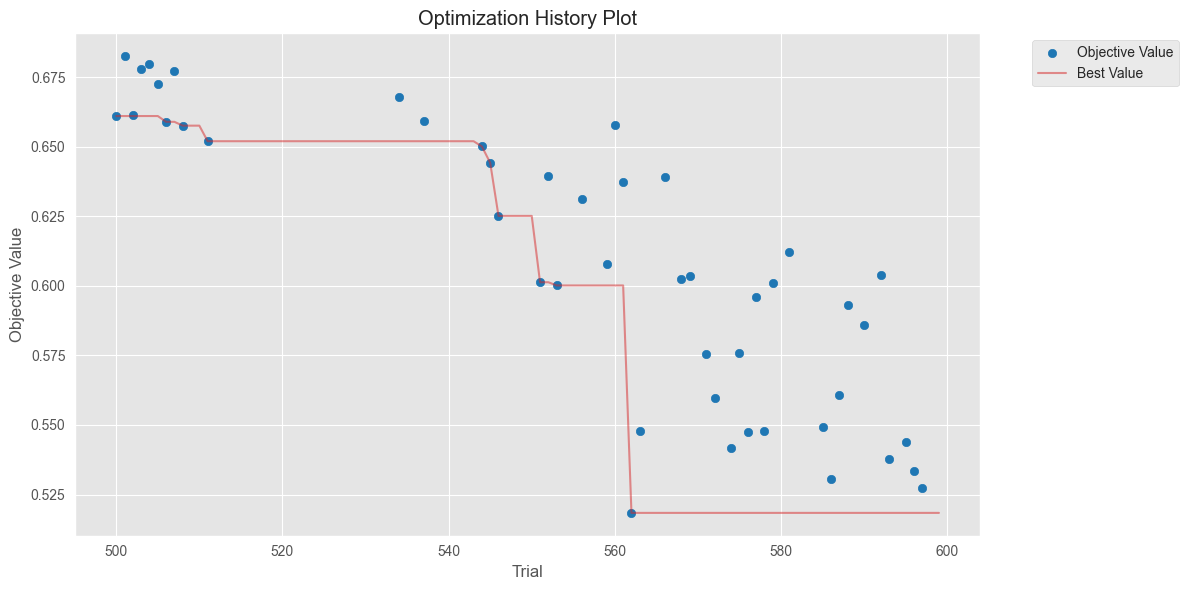

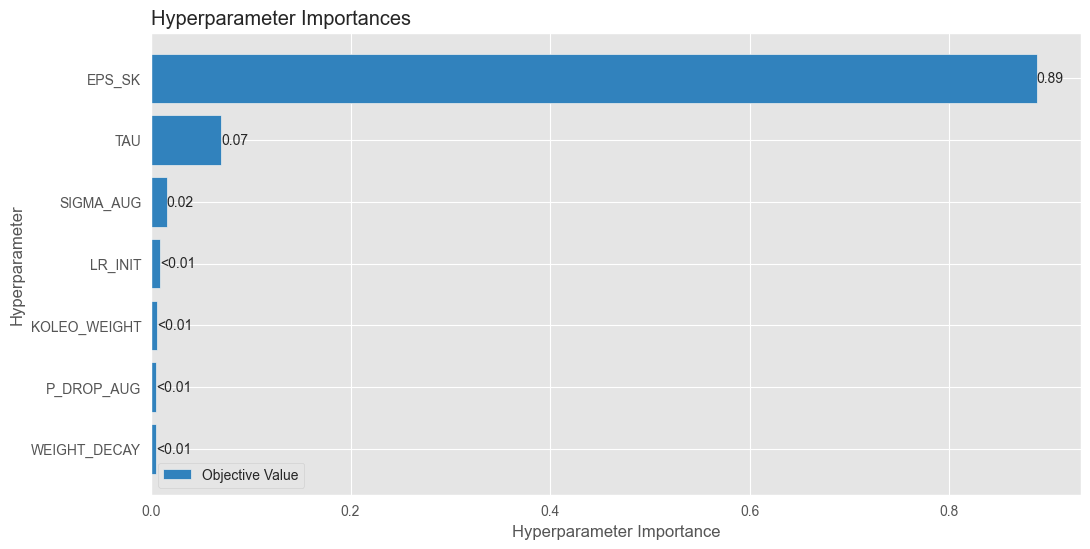

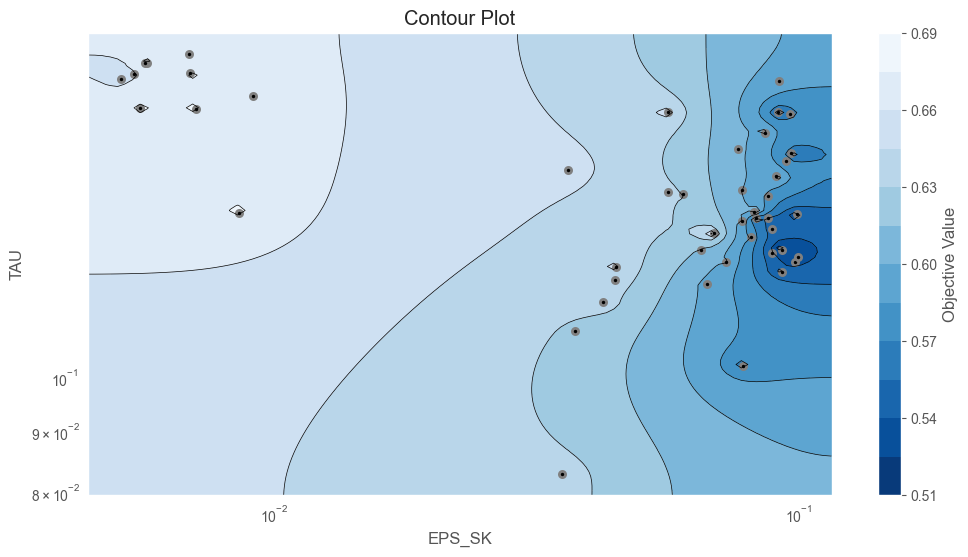

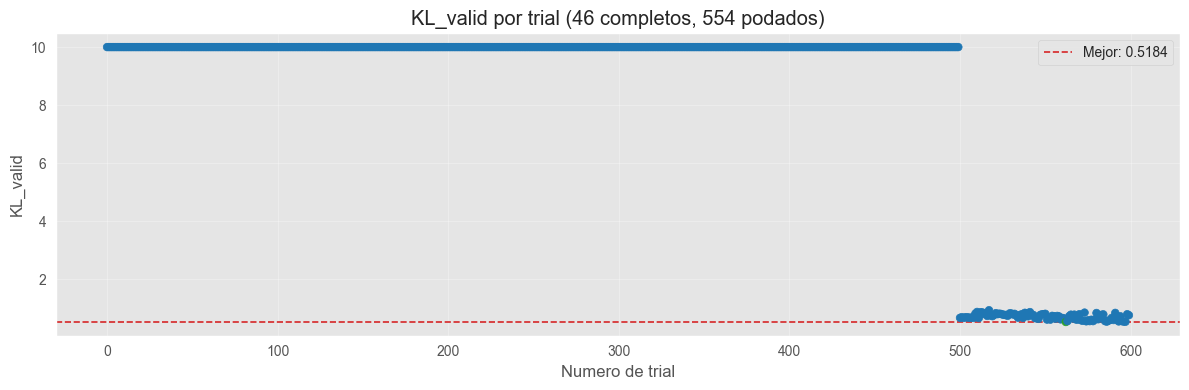


Variables globales actualizadas. Re-ejecuta la celda de entrenamiento.
  TAU=0.12791  EPS_SK=0.09302  SIGMA_AUG=0.03263
  LR_INIT=0.092124  KOLEO_WEIGHT=0.20123
  P_DROP_AUG=0.2039  WEIGHT_DECAY=4.38e-04


In [23]:
import optuna, os
optuna.logging.set_verbosity(optuna.logging.WARNING)

# === Configuracion del estudio ===
OPTUNA_TRIALS  = 100
OPTUNA_EPOCHS  = 80
OPTUNA_WARMUP  = 5
OPTUNA_SEED    = 99
OPTUNA_DB      = 'sqlite:///d:/trabajo/agroplus/modelado/optuna_llp_co_v1.db'
OPTUNA_STUDY   = 'llp_co_v2'

def objective(trial):
    # === Espacio de busqueda (7 hiperparametros) ===
    tau       = trial.suggest_float('TAU',          0.05, 0.2,  log=True)
    eps_sk    = trial.suggest_float('EPS_SK',       0.005, 0.10,  log=True)
    sigma     = trial.suggest_float('SIGMA_AUG',    0.01,  0.15,  log=True)
    lr_init   = trial.suggest_float('LR_INIT',      0.05,  0.3,  log=True)
    koleo_w   = trial.suggest_float('KOLEO_WEIGHT', 0.01,  0.50,  log=True)
    p_drop    = trial.suggest_float('P_DROP_AUG',   0.05,  0.40)
    wd        = trial.suggest_float('WEIGHT_DECAY', 1e-7,  1e-3,  log=True)

    torch.manual_seed(OPTUNA_SEED + trial.number)
    enc_t   = MLPEncoder(N_FEATURES, hidden_dims=(256, 128, 64),
                         emb_dim=EMB_DIM, dropout=0.2).to(DEVICE)
    proto_t = Prototypes(K, EMB_DIM).to(DEVICE)
    opt_t   = torch.optim.AdamW(
        list(enc_t.parameters()) + list(proto_t.parameters()),
        lr=lr_init, weight_decay=wd
    )

    rng_t    = np.random.RandomState(OPTUNA_SEED + trial.number)
    ids_list = list(bag_index_tr.keys())
    lr_min   = lr_init * 1e-2
    best_kl  = float('inf')

    for epoch in range(OPTUNA_EPOCHS):
        lr = cosine_warmup_lr(epoch, OPTUNA_EPOCHS, lr_init, lr_min, OPTUNA_WARMUP)
        for g in opt_t.param_groups:
            g['lr'] = lr

        for p in proto_t.parameters():
            p.requires_grad = (epoch >= FREEZE_PROTO_EPOCHS)

        rng_t.shuffle(ids_list)
        run_train_epoch(enc_t, proto_t, opt_t, ids_list, bag_index_tr,
                        X_train_t, W_mun_tr_t, tau, eps_sk, sigma, p_drop,
                        koleo_w, feat_groups, GRAD_CLIP, rng_t)

        kl_epoch = eval_kl(enc_t, proto_t, bag_index_va, X_valid_t, W_mun_va_t, tau)

        # Nota: removido check de colapso por max_uso > 0.60.
        # Con 18 clases y desbalance fuerte (Arveja 28%, Hortalizas 25%),
        # el prototipo dominante legitimamente puede tener >50% de uso.
        # MedianPruner basado en KL_valid maneja deteccion de trials malos.

        best_kl = min(best_kl, kl_epoch)
        trial.report(kl_epoch, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_kl


# === Estudio persistente en SQLite ===
os.makedirs('d:/trabajo/agroplus/modelado', exist_ok=True)

sampler = optuna.samplers.TPESampler(
    seed=OPTUNA_SEED,
    multivariate=True,
    n_startup_trials=12,
)
pruner = optuna.pruners.MedianPruner(
    n_startup_trials=8,
    n_warmup_steps=OPTUNA_WARMUP + 8,
    interval_steps=3,
)

study = optuna.create_study(
    study_name=OPTUNA_STUDY,
    storage=OPTUNA_DB,
    direction='minimize',
    sampler=sampler,
    pruner=pruner,
    load_if_exists=True,
)

n_prev = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
print(f'Estudio "{OPTUNA_STUDY}" | Trials completados previos: {n_prev}')
print(f'Lanzando {OPTUNA_TRIALS} trials x {OPTUNA_EPOCHS} epocas...')
print(f'Params: TAU, EPS_SK, SIGMA_AUG, LR_INIT, KOLEO_WEIGHT, P_DROP_AUG, WEIGHT_DECAY')
print(f'Sampler: TPE multivariado | Pruner: MedianPruner | DB: {OPTUNA_DB}')

t0_opt = time.time()
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)
print(f'Optuna completado en {(time.time()-t0_opt)/60:.1f} min')

# === Resultados ===
best = study.best_trial
print(f'\nMejor KL_valid : {best.value:.4f}  (trial #{best.number})')
print('Mejores hiperparametros:')
for k, v in best.params.items():
    print(f'  {k:<16} = {v:.6f}')

n_pruned   = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
print(f'Completados: {n_complete} | Podados: {n_pruned}')

# === Graficos de diagnostico ===
n_complete_diag = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
n_pruned_diag   = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
print(f'Trials completados: {n_complete_diag} | podados: {n_pruned_diag}')

try:
    fig_hist = optuna.visualization.matplotlib.plot_optimization_history(study)
    fig_hist.suptitle('Historia de optimizacion - KL_valid por trial', fontsize=12)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'plot_optimization_history: {e}')

if n_complete_diag >= 4:
    try:
        fig_imp = optuna.visualization.matplotlib.plot_param_importances(study)
        fig_imp.suptitle('Importancia de hiperparametros (fANOVA)', fontsize=12)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'plot_param_importances: {e}')
else:
    print(f'Importancia: se necesitan >= 4 trials completos (hay {n_complete_diag})')

if n_complete_diag >= 6:
    try:
        fig_cnt = optuna.visualization.matplotlib.plot_contour(
            study, params=['TAU', 'EPS_SK']
        )
        fig_cnt.suptitle('Contorno KL_valid: TAU vs EPS_SK', fontsize=12)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'plot_contour: {e}')

values = [(t.number, t.value) for t in study.trials if t.value is not None]
if values:
    nums, kls = zip(*values)
    fig_m, ax_m = plt.subplots(figsize=(12, 4))
    colors = ['#2ca02c' if kl == study.best_value else '#1f77b4' for kl in kls]
    ax_m.scatter(nums, kls, c=colors, s=30, zorder=3)
    ax_m.axhline(study.best_value, color='#d62728', linestyle='--', linewidth=1.2,
                 label=f'Mejor: {study.best_value:.4f}')
    ax_m.set_xlabel('Numero de trial')
    ax_m.set_ylabel('KL_valid')
    ax_m.set_title(f'KL_valid por trial ({n_complete_diag} completos, {n_pruned_diag} podados)')
    ax_m.legend(); ax_m.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

# === Actualizar variables globales con mejores hiperparametros ===
TAU          = best.params['TAU']
EPS_SK       = best.params['EPS_SK']
SIGMA_AUG    = best.params['SIGMA_AUG']
LR_INIT      = best.params['LR_INIT']
KOLEO_WEIGHT = best.params['KOLEO_WEIGHT']
P_DROP_AUG   = best.params['P_DROP_AUG']
WEIGHT_DECAY = best.params['WEIGHT_DECAY']

print('\nVariables globales actualizadas. Re-ejecuta la celda de entrenamiento.')
print(f'  TAU={TAU:.5f}  EPS_SK={EPS_SK:.5f}  SIGMA_AUG={SIGMA_AUG:.5f}')
print(f'  LR_INIT={LR_INIT:.6f}  KOLEO_WEIGHT={KOLEO_WEIGHT:.5f}')
print(f'  P_DROP_AUG={P_DROP_AUG:.4f}  WEIGHT_DECAY={WEIGHT_DECAY:.2e}')

In [24]:
torch.manual_seed(SEED)
np.random.seed(SEED)

encoder    = MLPEncoder(N_FEATURES, hidden_dims=(256, 128, 64), emb_dim=EMB_DIM, dropout=0.2).to(DEVICE)
prototypes = Prototypes(K, EMB_DIM).to(DEVICE)
optimizer  = torch.optim.AdamW(
    list(encoder.parameters()) + list(prototypes.parameters()),
    lr=LR_INIT, weight_decay=WEIGHT_DECAY
)

bag_ids_tr_list = list(bag_index_tr.keys())
history = {"epoch": [], "lr": [], "loss_train": [], "kl_valid": []}

print("Iniciando entrenamiento LLP-Co (bags dinamicos)...")
print(f"  {len(bag_ids_tr_list)} municipios procesados por epoch (Max pixeles/bag: {BAG_SIZE})")
t0 = time.time()

for epoch in range(TOTAL_EPOCHS):
    lr = cosine_warmup_lr(epoch, TOTAL_EPOCHS, LR_INIT, LR_MIN, WARMUP_EPOCHS)
    for g in optimizer.param_groups:
        g["lr"] = lr

    for p in prototypes.parameters():
        p.requires_grad = (epoch >= FREEZE_PROTO_EPOCHS)

    rng = np.random.RandomState(SEED + epoch)
    rng.shuffle(bag_ids_tr_list)

    loss_avg = run_train_epoch(encoder, prototypes, optimizer, bag_ids_tr_list,
                               bag_index_tr, X_train_t, W_mun_tr_t, TAU, EPS_SK,
                               SIGMA_AUG, P_DROP_AUG, KOLEO_WEIGHT, feat_groups,
                               GRAD_CLIP, rng)

    kl_avg = eval_kl(encoder, prototypes, bag_index_va, X_valid_t, W_mun_va_t, TAU)

    history["epoch"].append(epoch)
    history["lr"].append(lr)
    history["loss_train"].append(loss_avg)
    history["kl_valid"].append(kl_avg)

    print(f"Epoca {epoch+1:2d}/{TOTAL_EPOCHS}  lr={lr:.5f}  "
          f"loss_train={loss_avg:.4f}  KL_valid={kl_avg:.4f}  "
          f"({(time.time()-t0):.0f}s)")

print(f"Entrenamiento LLP-Co completado en {(time.time()-t0)/60:.1f} min.")


Iniciando entrenamiento LLP-Co (bags dinamicos)...
  81 municipios procesados por epoch (Max pixeles/bag: 2048)
Epoca  1/500  lr=0.01842  loss_train=5.1595  KL_valid=1.0286  (2s)
Epoca  2/500  lr=0.03685  loss_train=5.2888  KL_valid=1.1196  (3s)
Epoca  3/500  lr=0.05527  loss_train=4.6776  KL_valid=0.9509  (5s)
Epoca  4/500  lr=0.07370  loss_train=4.5327  KL_valid=0.8736  (7s)
Epoca  5/500  lr=0.09212  loss_train=4.4100  KL_valid=0.9157  (8s)
Epoca  6/500  lr=0.09212  loss_train=4.2334  KL_valid=0.8265  (10s)
Epoca  7/500  lr=0.09212  loss_train=4.1036  KL_valid=0.8581  (12s)
Epoca  8/500  lr=0.09212  loss_train=4.1195  KL_valid=0.8075  (13s)
Epoca  9/500  lr=0.09212  loss_train=4.0596  KL_valid=0.8351  (15s)
Epoca 10/500  lr=0.09211  loss_train=4.0413  KL_valid=0.8196  (17s)
Epoca 11/500  lr=0.09210  loss_train=4.0301  KL_valid=0.7716  (18s)
Epoca 12/500  lr=0.09209  loss_train=3.9835  KL_valid=0.8457  (20s)
Epoca 13/500  lr=0.09208  loss_train=4.0032  KL_valid=0.8078  (22s)
Epoca 14/

Pesos guardados en checkpoints\l2_llp_co.pt


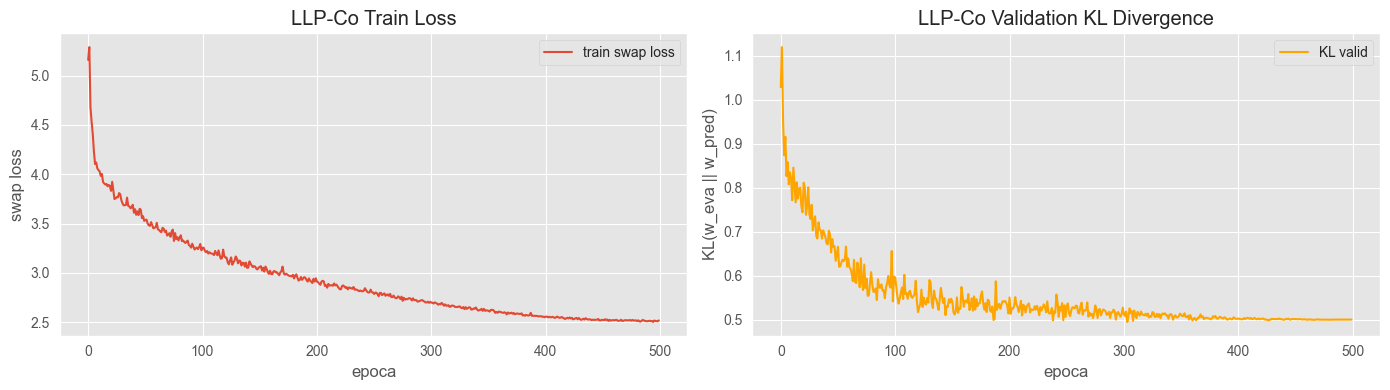

In [25]:
# === Persistir pesos del modelo L2 LLP-Co ===
torch.save({
    'encoder_state': encoder.state_dict(),
    'prototypes_state': prototypes.state_dict(),
    'config': {
        'n_features': N_FEATURES, 'K': K, 'emb_dim': EMB_DIM,
        'tau': TAU, 'eps_sk': EPS_SK,
    },
    'feature_cols': feature_cols,
    'classes': CLASES_FINALES,
    'history': history,
}, CKPT_DIR / 'l2_llp_co.pt')
print(f"Pesos guardados en {CKPT_DIR / 'l2_llp_co.pt'}")

# Plot de la curva de loss
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['epoch'], history['loss_train'], label='train swap loss')
axes[0].set_xlabel('epoca'); axes[0].set_ylabel('swap loss')
axes[0].set_title('LLP-Co Train Loss')
axes[0].legend()

axes[1].plot(history['epoch'], history['kl_valid'], label='KL valid', color='orange')
axes[1].set_xlabel('epoca'); axes[1].set_ylabel('KL(w_eva || w_pred)')
axes[1].set_title('LLP-Co Validation KL Divergence')
axes[1].legend()
plt.tight_layout()


In [ ]:
# === Persistir scaler para inferencia desde la API ===
# El scaler es necesario para transformar features nuevas en inferencia
# (pip install joblib si no esta instalado)
import joblib

joblib.dump(scaler, CKPT_DIR / 'l2_scaler.joblib')
print(f"Scaler guardado en {CKPT_DIR / 'l2_scaler.joblib'}")
print(f"  StandardScaler ajustado sobre X_train: {len(feature_cols)} features")
print(f"  Mean shape: {scaler.mean_.shape}, Scale shape: {scaler.scale_.shape}")


---
## 6. Evaluacion del modelo LLP-Co

Cinco métricas complementarias:

1. **Top-N predicciones** - el modelo produce `P(cultivo | pixel)` con **K=18** probabilidades.
   La salida natural es un **ranking** de cultivos, no una clase única.

2. **Métrica de bag** - `KL(w_eva || w_pred_promedio)` por municipio. Mide si las proporciones
   predichas a nivel municipio coinciden con las reportadas por EVA. Es la métrica nativa de LLP.

3. **Top-K Accuracy** - fracción de píxeles donde el cultivo pseudo-verdadero `argmax(W_eva)`
   aparece entre las K alternativas más probables. Top-1 = accuracy clásica; Top-3/5 es más
   apropiado para un modelo que predice distribuciones, no clases únicas.

4. **F1 macro y matriz de confusión** - usando `argmax(W_eva)` como pseudo-GT. Útil como sanity
   check pero subestima al modelo cuando predice distribuciones suaves correctas.

5. **Análisis de prototipos** - similitud coseno entre los K=18 vectores prototipo.

### 6.1 Predicciones del modelo


In [26]:
# === Predicciones LLP-Co en VALID y TEST ===
@torch.no_grad()
def predict_llp_co(X_arr, batch_size=4096):
    encoder.eval(); prototypes.eval()
    out = []
    for i in range(0, len(X_arr), batch_size):
        Xt = torch.from_numpy(X_arr[i:i+batch_size]).float().to(DEVICE)
        z = encoder(Xt)
        p = F.softmax(prototypes(z) / TAU, dim=-1).cpu().numpy()
        out.append(p)
    return np.vstack(out)


def top_n_predictions(P, n=5, id_to_name=None):
    """Top-N cultivos con sus probabilidades para cada pixel."""
    top_idx = np.argsort(P, axis=1)[:, ::-1][:, :n]
    top_probs = np.take_along_axis(P, top_idx, axis=1)
    rows = []
    for i in range(len(P)):
        row = {}
        for rank in range(n):
            cls_id = top_idx[i, rank]
            name = id_to_name[cls_id] if id_to_name else str(cls_id)
            row[f"top{rank+1}_cultivo"] = name
            row[f"top{rank+1}_prob"] = round(float(top_probs[i, rank]), 4)
        rows.append(row)
    return pd.DataFrame(rows)


P_llp_va = predict_llp_co(X_valid)
P_llp_te = predict_llp_co(X_test)

print(f"Probabilidades LLP-Co valid: {P_llp_va.shape}")
print(f"Probabilidades LLP-Co test:  {P_llp_te.shape}")

# Ejemplo: top-5 para los primeros 10 pixeles del valid
df_top5 = top_n_predictions(P_llp_va[:10], n=5, id_to_name=inv_catalogo)
print("Top-5 predicciones por pixel (primeros 10 pixeles del valid):")
print(df_top5.to_string(index=True))


Probabilidades LLP-Co valid: (420138, 18)
Probabilidades LLP-Co test:  (515961, 18)
Top-5 predicciones por pixel (primeros 10 pixeles del valid):
    top1_cultivo  top1_prob top2_cultivo  top2_prob top3_cultivo  top3_prob top4_cultivo  top4_prob top5_cultivo  top5_prob
0  Cana_Panelera     0.7135     Citricos     0.0647        Cacao     0.0607         Cafe     0.0600         Yuca     0.0516
1          Cacao     0.4051      Platano     0.1550     Citricos     0.1184         Yuca     0.1059         Maiz     0.0930
2  Cana_Panelera     0.5140        Cacao     0.1442     Citricos     0.1092         Yuca     0.0853      Platano     0.0759
3          Cacao     0.3935      Platano     0.1688         Maiz     0.1247     Citricos     0.1199         Yuca     0.0759
4  Cana_Panelera     0.8491         Cafe     0.0483     Citricos     0.0435         Yuca     0.0191        Cacao     0.0187
5  Cana_Panelera     0.9264         Cafe     0.0261     Citricos     0.0185         Yuca     0.0091        Cac

In [27]:
# === Metrica de bag: KL(w_eva || w_pred) por municipio ===
def kl_per_bag(P, bag_index, w_mun_dict, eps=1e-8):
    kls = {}
    for b, idx in bag_index.items():
        w_eva = w_mun_dict[b]
        p_pred = P[idx].mean(axis=0)
        kl = (w_eva * (np.log(w_eva + eps) - np.log(p_pred + eps))).sum()
        kls[b] = kl
    return kls

kl_llp_va = kl_per_bag(P_llp_va, bag_index_va, W_mun_va)
kl_arr = np.array(list(kl_llp_va.values()))

print(f"KL(w_eva || w_pred) en valid (por municipio):")
print(f"  mean   = {kl_arr.mean():.4f}")
print(f"  median = {np.median(kl_arr):.4f}")
print(f"  p25    = {np.percentile(kl_arr, 25):.4f}")
print(f"  p75    = {np.percentile(kl_arr, 75):.4f}")
print(f"  max    = {kl_arr.max():.4f}")
print()
print("Top-5 municipios con peor KL (mayor divergencia):")
sorted_kl = sorted(kl_llp_va.items(), key=lambda x: -x[1])
for mun, kl in sorted_kl[:5]:
    print(f"  mun={mun}  KL={kl:.4f}")


KL(w_eva || w_pred) en valid (por municipio):
  mean   = 0.5002
  median = 0.3610
  p25    = 0.2613
  p75    = 0.5263
  max    = 1.9479

Top-5 municipios con peor KL (mayor divergencia):
  mun=25279  KL=1.9479
  mun=25120  KL=1.0650
  mun=25312  KL=0.8510
  mun=25524  KL=0.5714
  mun=25148  KL=0.5112


In [28]:
# === Top-K Accuracy vs pseudo-GT (argmax W_eva) ===
y_va_pseudo = W_valid.argmax(axis=1)
y_te_pseudo = W_test.argmax(axis=1)

def topk_accuracy(P, y_true, k):
    """Fraccion de pixeles donde y_true esta en el top-k predicciones."""
    top_k = np.argsort(P, axis=1)[:, ::-1][:, :k]
    return (top_k == y_true[:, None]).any(axis=1).mean()

print("Top-K Accuracy vs pseudo-GT:")
print(f"{'':<12} {"valid":>10} {"test":>10}")
print("-" * 35)
for k in [1, 3, 5, 8]:
    acc_va = topk_accuracy(P_llp_va, y_va_pseudo, k)
    acc_te = topk_accuracy(P_llp_te, y_te_pseudo, k)
    print(f"  Top-{k}:     {acc_va:>10.4f} {acc_te:>10.4f}")

print()
print("Nota: Top-1 = accuracy clasica. Top-3/5/8 mide si el cultivo verdadero")
print("      aparece entre las K alternativas mas probables del modelo.")


Top-K Accuracy vs pseudo-GT:
                  valid       test
-----------------------------------
  Top-1:         0.5397     0.8770
  Top-3:         0.8225     0.9594
  Top-5:         0.8957     0.9836
  Top-8:         0.9743     0.9944

Nota: Top-1 = accuracy clasica. Top-3/5/8 mide si el cultivo verdadero
      aparece entre las K alternativas mas probables del modelo.


In [29]:
# === Evaluacion correcta: Hungarian match (paper La Rosa et al. 2022, Sec. V) ===
# El paper asigna cada prototipo a una clase con el algoritmo Hungaro antes de
# calcular accuracy o confusion matrix. Sin esto, el cluster swap hace Acc_P < Acc_H.

from scipy.optimize import linear_sum_assignment

y_va_pseudo = W_valid.argmax(axis=1)
y_te_pseudo = W_test.argmax(axis=1)
pred_clusters_va = P_llp_va.argmax(axis=1)
pred_clusters_te = P_llp_te.argmax(axis=1)

# Matriz de coincidencia: filas=prototipos, columnas=clases pseudo-GT
cost_matrix = np.zeros((K_FINAL, K_FINAL), dtype=np.int64)
for proto, cls in zip(pred_clusters_va, y_va_pseudo):
    cost_matrix[proto, cls] += 1

# Maximizar coincidencias (linear_sum_assignment minimiza, negamos la matriz)
row_ind, col_ind = linear_sum_assignment(-cost_matrix)
proto_to_class = {int(p): int(c) for p, c in zip(row_ind, col_ind)}

pred_hungarian_va = np.array([proto_to_class[p] for p in pred_clusters_va])
pred_hungarian_te = np.array([proto_to_class[p] for p in pred_clusters_te])

# Acc_P: asignacion directa | Acc_H: post-Hungarian
acc_p_va = (pred_clusters_va == y_va_pseudo).mean()
acc_h_va = (pred_hungarian_va == y_va_pseudo).mean()
acc_p_te = (pred_clusters_te == y_te_pseudo).mean()
acc_h_te = (pred_hungarian_te == y_te_pseudo).mean()

print('=' * 52)
print('Acc_P vs Acc_H  (paper Sec. V)')
print('=' * 52)
print(f"{'':20} {'valid':>10} {'test':>10}")
print(f"  Acc_P (directo)   {acc_p_va:>10.4f} {acc_p_te:>10.4f}")
print(f"  Acc_H (Hungaro)   {acc_h_va:>10.4f} {acc_h_te:>10.4f}")
print(f"  Swap effect       {acc_h_va-acc_p_va:>+10.4f} {acc_h_te-acc_p_te:>+10.4f}")
print()
print('Asignacion Hungarian (prototipo -> clase):')
for proto, cls in sorted(proto_to_class.items()):
    n_assigned = (pred_clusters_va == proto).sum()
    print(f'  Proto {proto:2d} -> {inv_catalogo[cls]:<20} ({n_assigned:,} pixeles valid)')


Acc_P vs Acc_H  (paper Sec. V)
                          valid       test
  Acc_P (directo)       0.5397     0.8770
  Acc_H (Hungaro)       0.5601     0.8453
  Swap effect          +0.0204    -0.0317

Asignacion Hungarian (prototipo -> clase):
  Proto  0 -> Cana_Panelera        (3,805 pixeles valid)
  Proto  1 -> Cafe                 (21,653 pixeles valid)
  Proto  2 -> Citricos             (11,805 pixeles valid)
  Proto  3 -> Cacao                (3,393 pixeles valid)
  Proto  4 -> Mango                (1,618 pixeles valid)
  Proto  5 -> Hortalizas           (11,527 pixeles valid)
  Proto  6 -> Banano               (1,199 pixeles valid)
  Proto  7 -> Arveja               (6,406 pixeles valid)
  Proto  8 -> Platano              (5 pixeles valid)
  Proto  9 -> Zanahoria            (1,315 pixeles valid)
  Proto 10 -> Yuca                 (187 pixeles valid)
  Proto 11 -> Maiz                 (9,477 pixeles valid)
  Proto 12 -> Palma                (2,632 pixeles valid)
  Proto 13 -> Toma

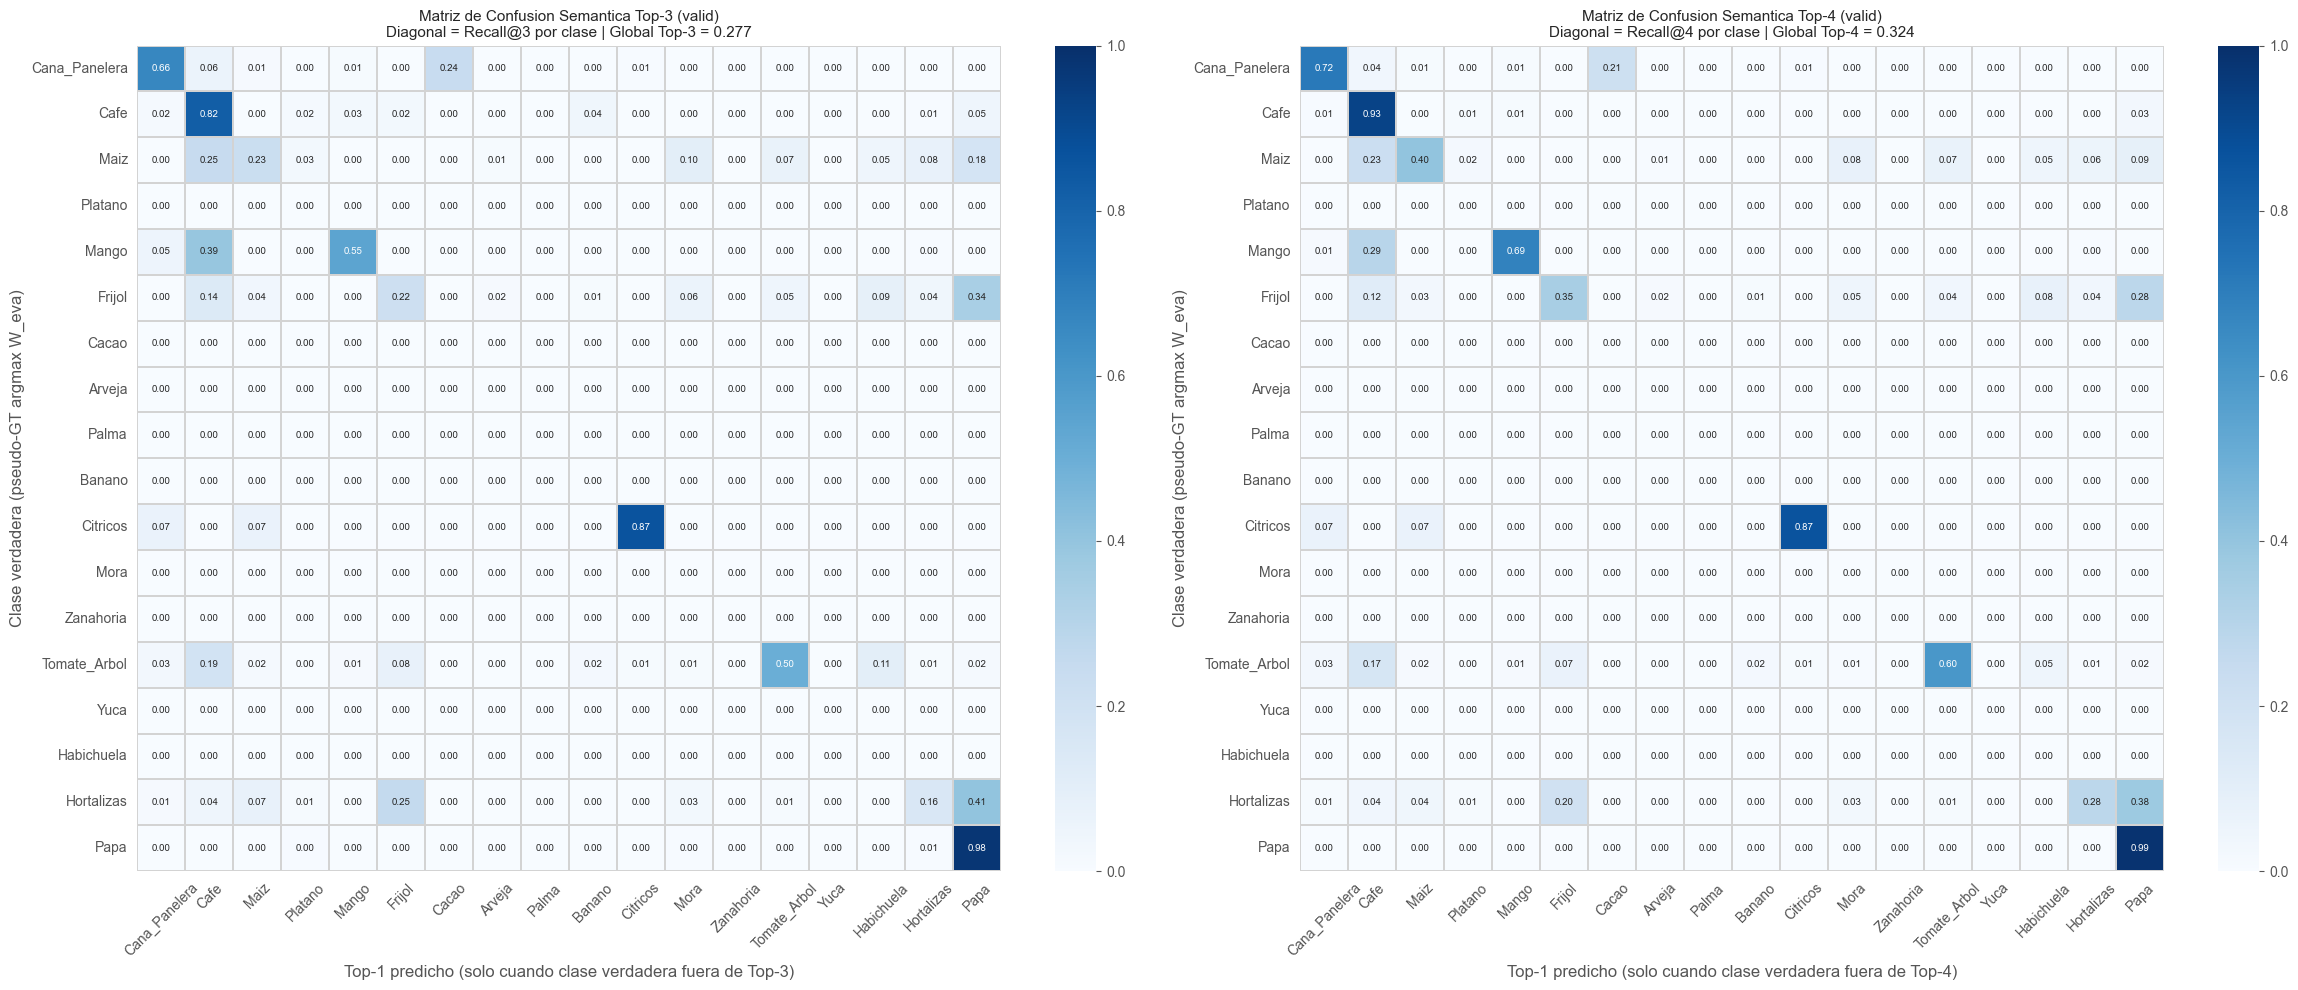


Recall por clase (valid):
Cultivo                  n_pix     R@1     R@2     R@3     R@5
------------------------------------------------------------
  Cana_Panelera          3,987   0.389   0.576   0.664   0.780
  Cafe                   9,846   0.487   0.683   0.821   0.958
  Maiz                  20,048   0.005   0.100   0.230   0.530  <<
  Mango                  1,677   0.465   0.494   0.546   0.711
  Frijol                32,679   0.083   0.144   0.219   0.571  <<
  Citricos                 105   0.038   0.762   0.867   0.867
  Tomate_Arbol           1,926   0.064   0.261   0.503   0.678
  Hortalizas            24,837   0.032   0.084   0.156   0.392  <<
  Papa                 325,033   0.664   0.834   0.976   0.991
------------------------------------------------------------
  MACRO avg            420,138   0.124   0.219   0.277   0.360


In [30]:
# === Matriz de Confusion Semantica Top-K ===
# Estandar de oro en clasificacion de tierras agricolas (La Rosa 2022, ISPRS, etc.).
# Diagonal: fraccion de pixeles donde la clase verdadera esta en el Top-K del modelo.
# Off-diagonal: cuando el modelo falla (clase verdadera fuera de Top-K),
#   muestra a que clase fue asignado el Top-1.
#
# Un Top-3 Accuracy > 80% significa que el modelo redujo 16 opciones a 3 altamente
# probables, suficiente para asistir decision agronoma.

def topk_confusion_matrix(P, y_true, k, n_classes):
    """
    cm[i, i] = pixeles de clase i donde y_true esta en top-K  (hits)
    cm[i, j] = pixeles de clase i donde top-1 fue j pero y_true NO estaba en top-K  (misses)
    """
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    top_k_idx = np.argsort(P, axis=1)[:, ::-1][:, :k]  # (N, k)
    top1 = top_k_idx[:, 0]
    for i in range(len(y_true)):
        cls = y_true[i]
        if cls in top_k_idx[i]:
            cm[cls, cls] += 1
        else:
            cm[cls, top1[i]] += 1
    return cm


y_va_pseudo = W_valid.argmax(axis=1)
nombres = [inv_catalogo[i] for i in range(K_FINAL)]

# Calcular para K = 2 y K = 3
fig, axes = plt.subplots(1, 2, figsize=(24, 10))
#fig, axes = plt.subplots(1, 2, figsize=(24, 10))

#for ax, k in zip(axes, [2, 3]):
for ax, k in zip(axes, [3 , 4]):
    cm_k = topk_confusion_matrix(P_llp_va, y_va_pseudo, k=k, n_classes=K_FINAL)
    row_totals = cm_k.sum(axis=1, keepdims=True).clip(min=1)
    cm_norm = cm_k / row_totals  # recall@K en diagonal, confusion en off-diagonal

    # Mascara visual: diagonal en azul solido, off-diagonal mas tenue
    mask_diag = np.eye(K_FINAL, dtype=bool)
    sns.heatmap(cm_norm, ax=ax, cmap='Blues', vmin=0, vmax=1,
                xticklabels=nombres, yticklabels=nombres,
                annot=True, fmt='.2f', annot_kws={'size': 7},
                linewidths=0.3, linecolor='lightgray')

    # Resaltar diagonal con borde negro
    #for j in range(K_FINAL):
    #    ax.add_patch(plt.Rectangle((j, j), 1, 1, fill=False,
    #                               edgecolor='#1565C0', lw=2))

    recall_k = np.diag(cm_norm)
    global_topk = recall_k.mean()
    ax.set_title(
        f'Matriz de Confusion Semantica Top-{k} (valid)\n'
        f'Diagonal = Recall@{k} por clase | '
        f'Global Top-{k} = {global_topk:.3f}',
        fontsize=11
    )
    ax.set_xlabel(f'Top-1 predicho (solo cuando clase verdadera fuera de Top-{k})')
    ax.set_ylabel('Clase verdadera (pseudo-GT argmax W_eva)')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# --- Tabla de Recall@K por clase ---
print(f'\nRecall por clase (valid):')
print(f"{'Cultivo':<22} {'n_pix':>7} {'R@1':>7} {'R@2':>7} {'R@3':>7} {'R@5':>7}")
print('-' * 60)
cm1 = topk_confusion_matrix(P_llp_va, y_va_pseudo, k=1, n_classes=K_FINAL)
cm2 = topk_confusion_matrix(P_llp_va, y_va_pseudo, k=2, n_classes=K_FINAL)
cm3 = topk_confusion_matrix(P_llp_va, y_va_pseudo, k=3, n_classes=K_FINAL)
cm5 = topk_confusion_matrix(P_llp_va, y_va_pseudo, k=5, n_classes=K_FINAL)
for cls_id in range(K_FINAL):
    n = cm3[cls_id].sum()
    if n == 0:
        continue
    r1 = cm1[cls_id, cls_id] / n
    r2 = cm2[cls_id, cls_id] / n
    r3 = cm3[cls_id, cls_id] / n
    r5 = cm5[cls_id, cls_id] / n
    flag = '  <<' if r3 < 0.5 else ''
    print(f"  {inv_catalogo[cls_id]:<20} {n:>7,} {r1:>7.3f} {r2:>7.3f} {r3:>7.3f} {r5:>7.3f}{flag}")
print('-' * 60)
n_all = len(y_va_pseudo)
print(f"  {'MACRO avg':<20} {n_all:>7,} "
      f"{np.diag(cm1/cm1.sum(axis=1,keepdims=True).clip(1)).mean():>7.3f} "
      f"{np.diag(cm2/cm2.sum(axis=1,keepdims=True).clip(1)).mean():>7.3f} "
      f"{np.diag(cm3/cm3.sum(axis=1,keepdims=True).clip(1)).mean():>7.3f} "
      f"{np.diag(cm5/cm5.sum(axis=1,keepdims=True).clip(1)).mean():>7.3f}")


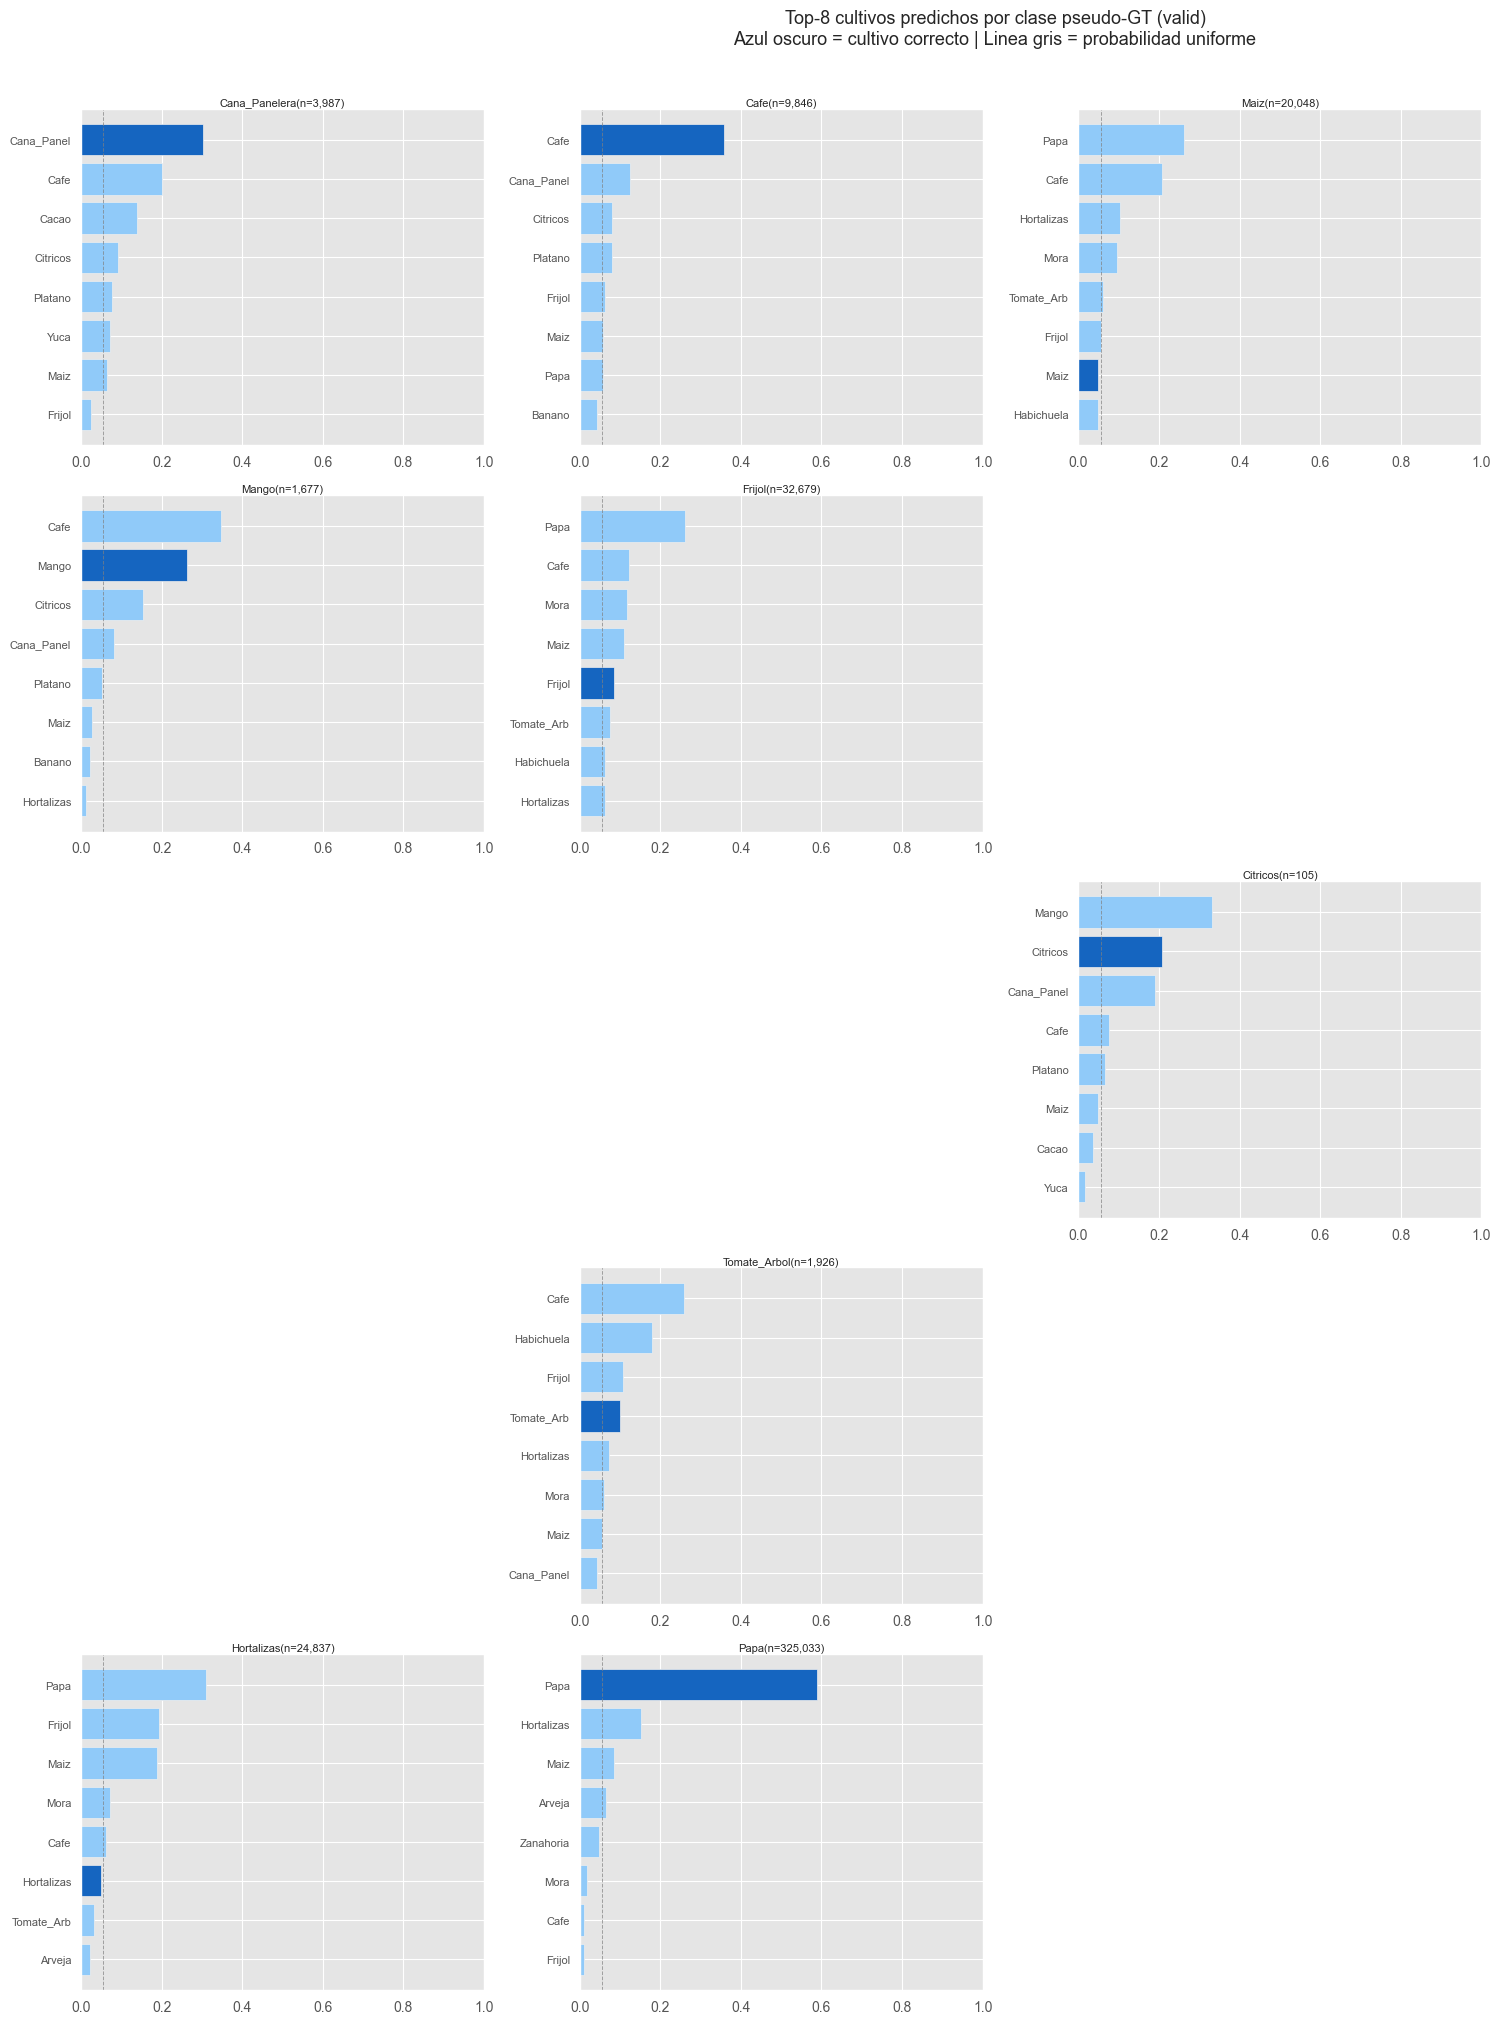

In [32]:
# === Distribucion de probabilidades predichas por clase pseudo-GT (valid) ===
# Para cada cultivo verdadero muestra las top-8 alternativas predichas por el modelo.
import math
y_va_pseudo = W_valid.argmax(axis=1)

# Grid dinamico segun K_FINAL (4 columnas, filas variables)
N_COLS = 4
N_ROWS = math.ceil(K_FINAL / N_COLS)
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(20, 4 * N_ROWS))
axes = axes.flatten()

for cls_id in range(K_FINAL):
    ax = axes[cls_id]
    cls_name = inv_catalogo[cls_id]
    mask = y_va_pseudo == cls_id
    n_pix = mask.sum()

    if n_pix == 0:
        ax.set_visible(False)
        continue

    mean_probs = P_llp_va[mask].mean(axis=0)
    top_idx_plot = np.argsort(mean_probs)[::-1][:8]
    top_names = [inv_catalogo[i][:10] for i in top_idx_plot]
    top_vals = mean_probs[top_idx_plot]
    colors = ["#1565C0" if i == cls_id else "#90CAF9" for i in top_idx_plot]

    ax.barh(range(len(top_names)), top_vals, color=colors)
    ax.set_yticks(range(len(top_names)))
    ax.set_yticklabels(top_names, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.set_title(f"{cls_name}(n={n_pix:,})", fontsize=8, pad=2)
    ax.axvline(x=1/K_FINAL, color="gray", linestyle="--", linewidth=0.7, alpha=0.7)

# Ocultar subplots vacios (cuando K_FINAL no llena el grid)
for j in range(K_FINAL, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Top-8 cultivos predichos por clase pseudo-GT (valid)\n"
    "Azul oscuro = cultivo correcto | Linea gris = probabilidad uniforme",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

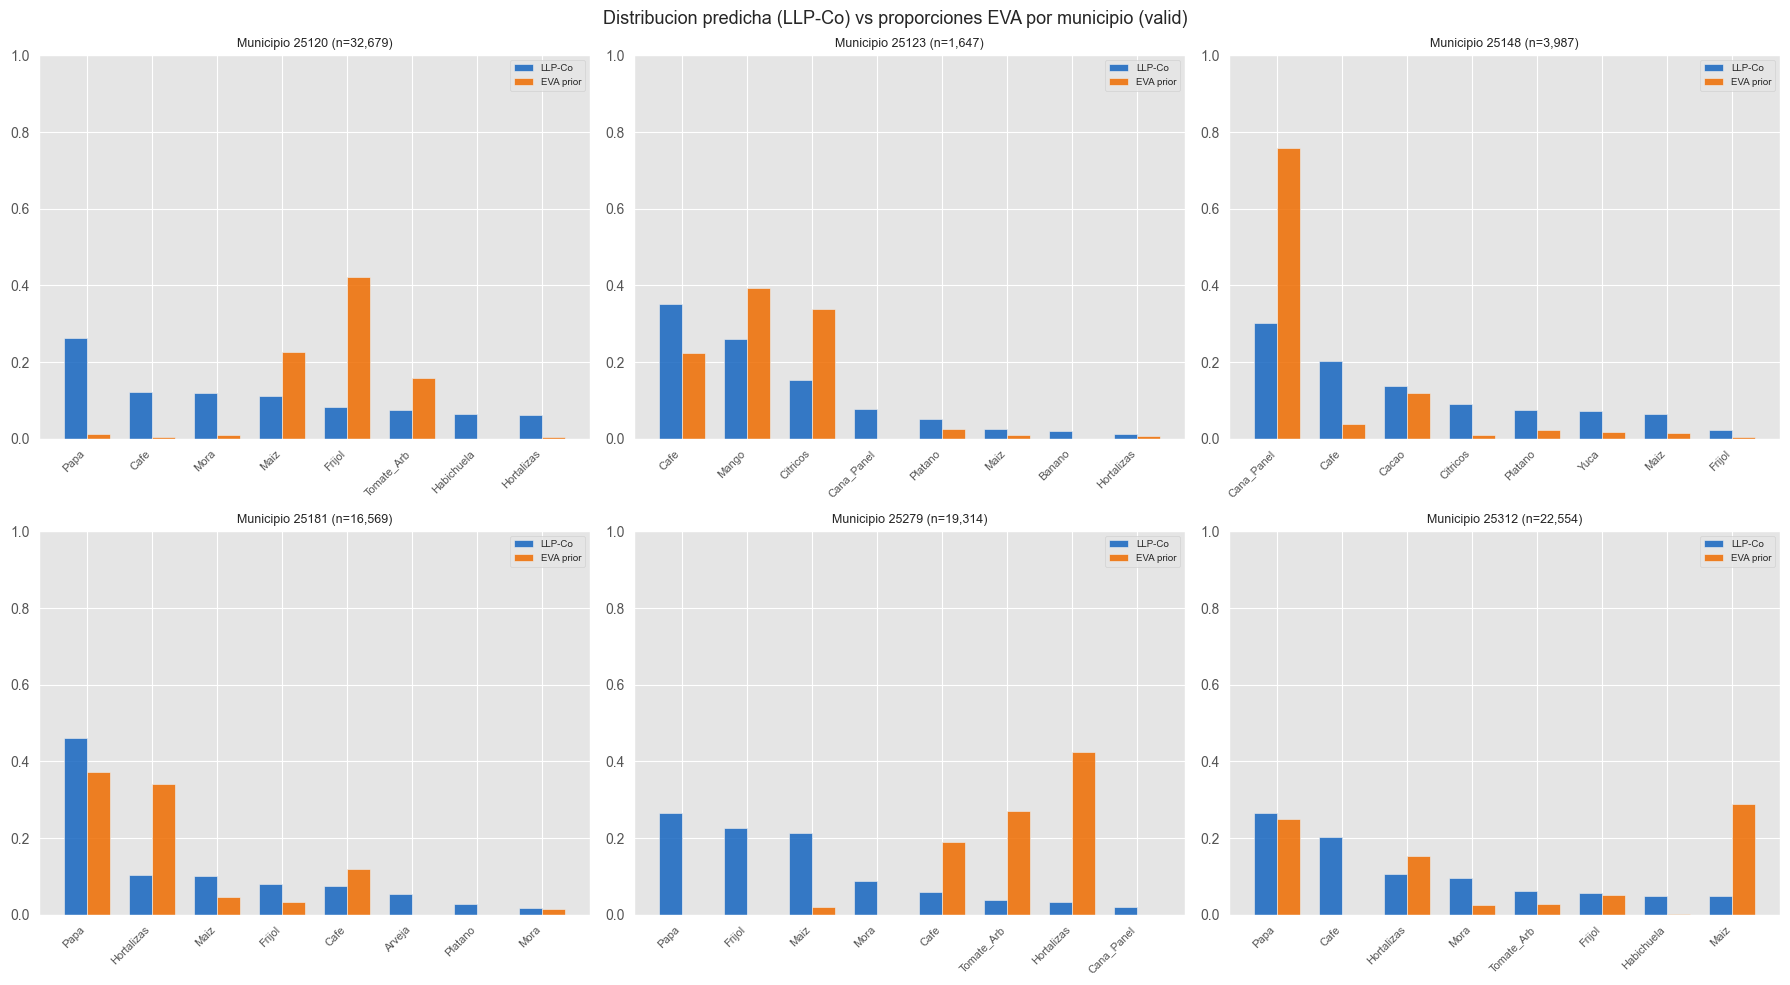

In [33]:
# === Distribucion predicha vs proporciones EVA por municipio (valid) ===
# Compara la distribucion agregada del modelo con el prior EVA para 6 municipios.
sample_muns = sorted(bag_index_va.keys())[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, mun in zip(axes, sample_muns):
    idx = bag_index_va[mun]
    p_mean = P_llp_va[idx].mean(axis=0)
    w_eva = W_mun_va[mun]

    order = np.argsort(p_mean)[::-1][:8]
    names = [inv_catalogo[i][:10] for i in order]
    pred_vals = p_mean[order]
    eva_vals = w_eva[order]

    x = np.arange(len(names))
    width = 0.35
    ax.bar(x - width/2, pred_vals, width, label="LLP-Co", color="#1565C0", alpha=0.85)
    ax.bar(x + width/2, eva_vals, width, label="EVA prior", color="#EF6C00", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"Municipio {mun} (n={len(idx):,})", fontsize=9)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)

plt.suptitle(
    "Distribucion predicha (LLP-Co) vs proporciones EVA por municipio (valid)",
    fontsize=13
)
plt.tight_layout()
plt.show()


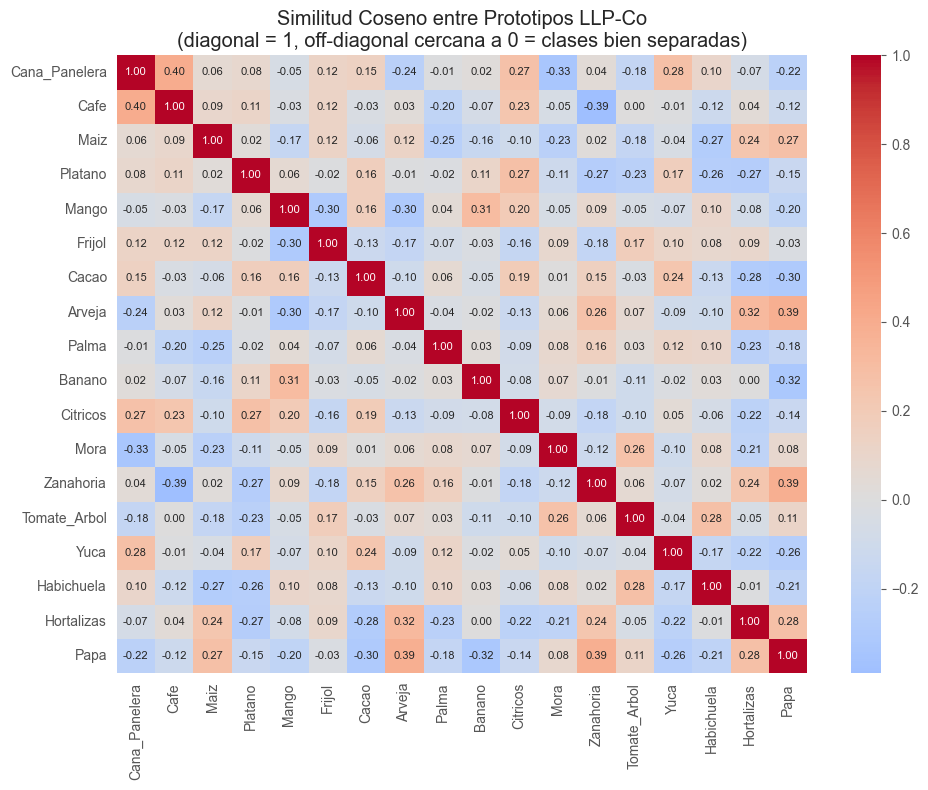

In [34]:
# === Analisis de prototipos LLP-Co (similitud coseno entre prototipos) ===
with torch.no_grad():
    V = prototypes.normed().cpu().numpy()  # (K, emb)
sim = V @ V.T

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=CLASES_FINALES, yticklabels=CLASES_FINALES, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Similitud Coseno entre Prototipos LLP-Co\n(diagonal = 1, off-diagonal cercana a 0 = clases bien separadas)')
plt.tight_layout()


In [35]:
# === Validacion externa UPRA: prediccion de Papa contra etiqueta de campo ===
# Los pixeles de fuente='monitoreo' tienen:
#   - prob_*: distribucion EVA del municipio (senal LLP para entrenamiento)
#   - cultivo='Papa' + fuente='monitoreo': etiqueta UPRA ground truth
# Evaluamos si LLP-Co coloca Papa en su top-K usando esa etiqueta como referencia.

import torch.nn.functional as F

df_upra = df_l2[df_l2['fuente'] == 'monitoreo'].copy()
print(f"Pixeles UPRA en df_l2: {len(df_upra):,}")
print(f"Distribucion cultivo UPRA: {df_upra['cultivo'].value_counts().to_dict()}")
print()

if len(df_upra) == 0:
    print("Sin pixeles monitoreo en df_l2. Verificar filtro de fuente.")
else:
    # Imputar NaN con mediana (mismo proceso que training)
    X_upra_raw = df_upra[feature_cols].values.copy()
    for j in range(X_upra_raw.shape[1]):
        nans = np.isnan(X_upra_raw[:, j])
        if nans.any():
            med = np.nanmedian(X_upra_raw[~nans, j]) if (~nans).any() else 0.0
            X_upra_raw[nans, j] = med

    X_upra = scaler.transform(X_upra_raw)

    # Prediccion LLP-Co (encoder + prototipos entrenados)
    encoder.eval(); prototypes.eval()
    with torch.no_grad():
        Xt = torch.from_numpy(X_upra).float().to(DEVICE)
        z  = encoder(Xt)
        P_upra = F.softmax(prototypes(z) / TAU, dim=-1).cpu().numpy()

    papa_idx = catalogo['Papa']
    mask_papa = (df_upra['cultivo'].values == 'Papa')

    print('=' * 52)
    print('Recall@K UPRA  (etiqueta campo UPRA como ground truth)')
    print('=' * 52)
    for k in [1, 2, 3, 5]:
        top_k = np.argsort(P_upra, axis=1)[:, ::-1][:, :k]
        en_topk = (top_k == papa_idx).any(axis=1)
        n_papa = int(mask_papa.sum())
        recall = float(en_topk[mask_papa].mean()) if n_papa > 0 else float('nan')
        print(f"  Recall@{k}: {recall:.3f}  "
              f"({int(en_topk[mask_papa].sum())}/{n_papa} pixeles Papa UPRA)")

    # Distribucion top-1 sobre pixeles Papa UPRA
    top1_papa = np.argsort(P_upra[mask_papa], axis=1)[:, ::-1][:, 0]
    from collections import Counter
    dist_top1 = Counter(inv_catalogo[i] for i in top1_papa)
    print()
    print('Top-1 predicho para pixeles Papa UPRA:')
    for cultivo_pred, cnt in dist_top1.most_common(8):
        pct = cnt / len(top1_papa) * 100
        print(f"  {cultivo_pred:<18} {cnt:>6,}  ({pct:.1f}%)")  

Pixeles UPRA en df_l2: 480,222
Distribucion cultivo UPRA: {'Papa': 425767, 'Otros_cultivos': 54455}

Recall@K UPRA  (etiqueta campo UPRA como ground truth)
  Recall@1: 0.737  (313938/425767 pixeles Papa UPRA)
  Recall@2: 0.873  (371596/425767 pixeles Papa UPRA)
  Recall@3: 0.973  (414146/425767 pixeles Papa UPRA)
  Recall@5: 0.988  (420538/425767 pixeles Papa UPRA)

Top-1 predicho para pixeles Papa UPRA:
  Papa               313,938  (73.7%)
  Hortalizas         77,415  (18.2%)
  Arveja              8,692  (2.0%)
  Maiz                6,616  (1.6%)
  Zanahoria           6,521  (1.5%)
  Cafe                4,115  (1.0%)
  Frijol              2,143  (0.5%)
  Mora                2,079  (0.5%)


In [36]:
# === Pieza 1: Predicciones LLP-Co sobre df_l2 completo (mapas espaciales) ===
# Aplicar mismo scaler entrenado + encoder + prototipos a TODOS los pixeles
# de df_l2 (train + valid + test).

# X_full ya esta imputado (NaN -> mediana) desde la celda de preprocesamiento.
X_full_scaled = scaler.transform(X_full)
print(f"X_full_scaled: {X_full_scaled.shape}")

P_full = predict_llp_co(X_full_scaled)
y_full_pred = P_full.argmax(axis=1)
print(f"P_full: {P_full.shape}  | y_full_pred: {y_full_pred.shape}")
print()
print("Distribucion de argmax(P_full) por cultivo:")
from collections import Counter
for cls_id, cnt in sorted(Counter(y_full_pred.tolist()).items(), key=lambda x: -x[1]):
    print(f"  {inv_catalogo[cls_id]:<18} {cnt:>10,}  ({cnt/len(y_full_pred)*100:.1f}%)")

X_full_scaled: (2812460, 29)
P_full: (2812460, 18)  | y_full_pred: (2812460,)

Distribucion de argmax(P_full) por cultivo:
  Papa                1,742,981  (62.0%)
  Hortalizas            435,614  (15.5%)
  Cafe                  122,394  (4.4%)
  Maiz                   98,797  (3.5%)
  Palma                  93,301  (3.3%)
  Frijol                 59,353  (2.1%)
  Arveja                 59,137  (2.1%)
  Zanahoria              39,140  (1.4%)
  Cana_Panelera          31,513  (1.1%)
  Mora                   28,838  (1.0%)
  Platano                23,583  (0.8%)
  Habichuela             17,690  (0.6%)
  Banano                 16,256  (0.6%)
  Tomate_Arbol           14,141  (0.5%)
  Cacao                  10,599  (0.4%)
  Mango                   9,971  (0.4%)
  Yuca                    5,226  (0.2%)
  Citricos                3,926  (0.1%)


In [37]:
# === Pieza 2: Funcion pixel_grid (raster a 250m) ===
# Agrega valores en celdas de 250m promediando los pixeles de 50m caidos en cada celda.
# Retorna grid 2D (H, W) con NaN donde no hay datos, y extent para imshow.

def pixel_grid(x, y, values, resolution=250, fill=np.nan):
    x = np.asarray(x).astype(np.float64)
    y = np.asarray(y).astype(np.float64)
    values = np.asarray(values).astype(np.float64)

    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()

    col = ((x - x_min) / resolution).astype(int)
    row = ((y_max - y) / resolution).astype(int)
    H = int(row.max()) + 1
    W = int(col.max()) + 1

    sum_grid = np.zeros((H, W), dtype=np.float64)
    cnt_grid = np.zeros((H, W), dtype=np.int32)
    np.add.at(sum_grid, (row, col), values)
    np.add.at(cnt_grid, (row, col), 1)

    grid = np.full((H, W), fill, dtype=np.float32)
    mask = cnt_grid > 0
    grid[mask] = (sum_grid[mask] / cnt_grid[mask]).astype(np.float32)

    extent = (x_min, x_min + W * resolution, y_max - H * resolution, y_max)
    return grid, extent

x_arr = df_l2['x'].values
y_arr = df_l2['y'].values
print(f"Bbox: x=[{x_arr.min():,.0f}, {x_arr.max():,.0f}]  "
      f"y=[{y_arr.min():,.0f}, {y_arr.max():,.0f}]")
print(f"Extent aprox: {(x_arr.max() - x_arr.min())/1000:.1f} km x "
      f"{(y_arr.max() - y_arr.min())/1000:.1f} km")

Bbox: x=[918,116, 1,109,073]  y=[904,932, 1,128,271]
Extent aprox: 191.0 km x 223.3 km


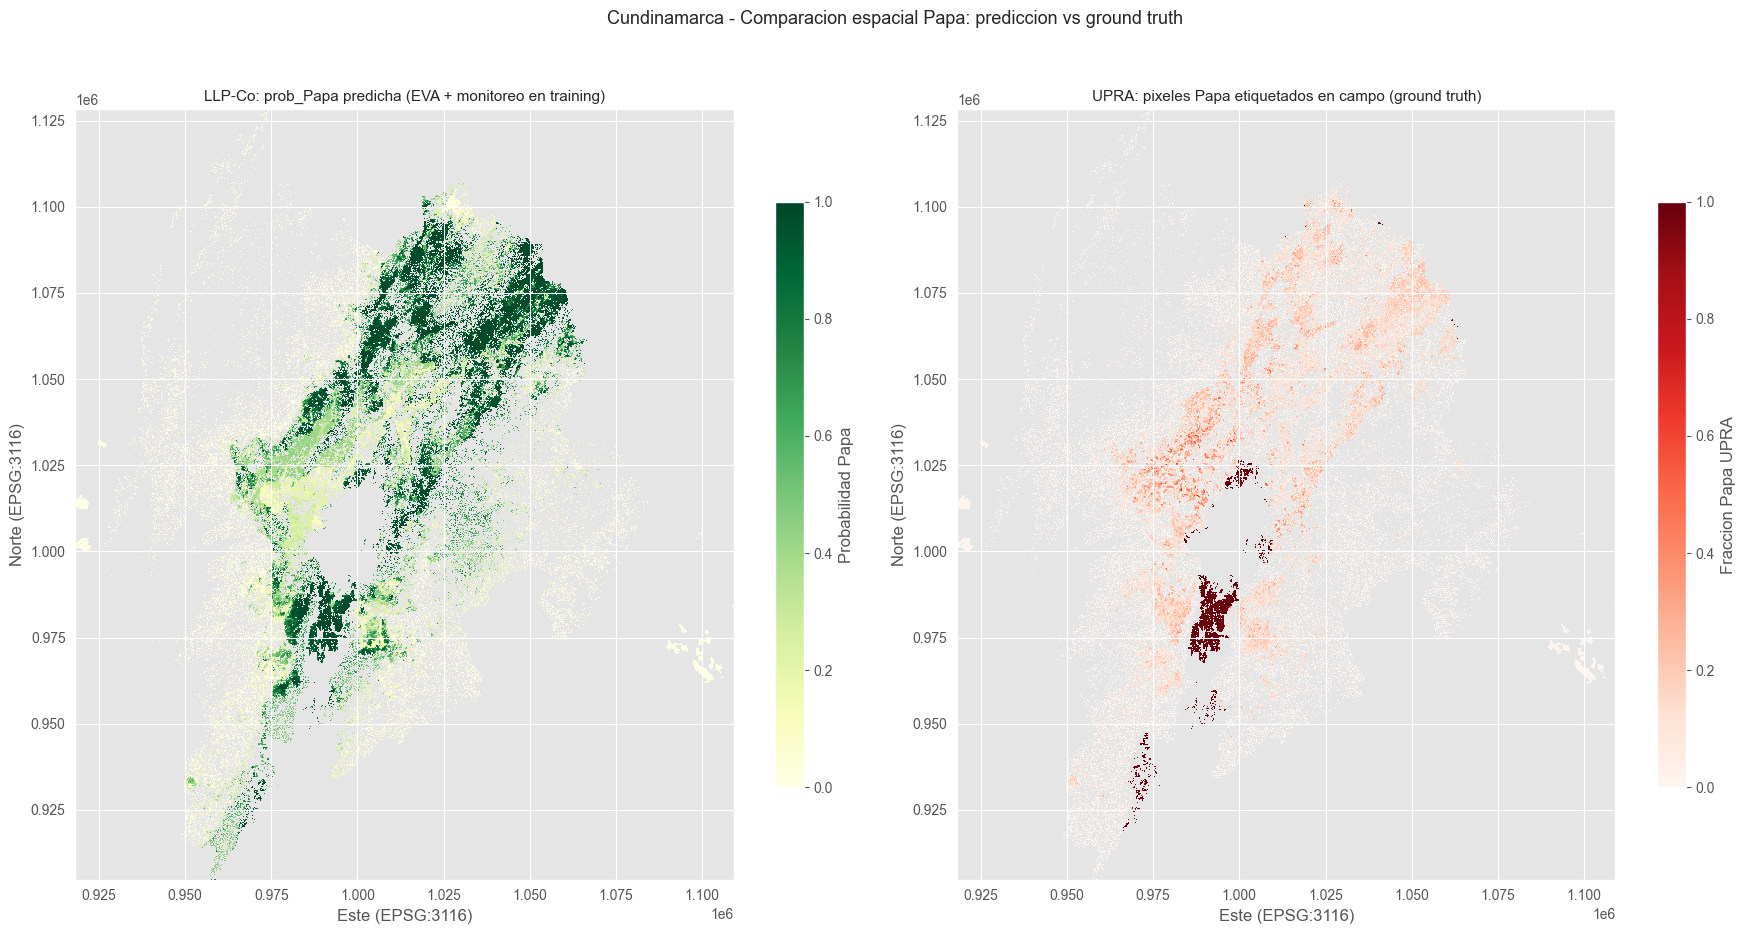

In [50]:
# === Pieza 3: Mapa de Papa - prediccion LLP-Co vs etiqueta UPRA ===
# Izquierda: prob_Papa predicha por el modelo (escala continua).
# Derecha:   pixeles UPRA etiquetados como Papa (binario, ground truth campo).

papa_idx = catalogo['Papa']
prob_papa_pred = P_full[:, papa_idx]
mask_upra_papa = ((df_l2['fuente'] == 'monitoreo') &
                  (df_l2['cultivo'] == 'Papa')).values.astype(np.float32)

grid_pred, ext = pixel_grid(x_arr, y_arr, prob_papa_pred, resolution=250)
grid_upra, _   = pixel_grid(x_arr, y_arr, mask_upra_papa,  resolution=250)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

im1 = axes[0].imshow(grid_pred, extent=ext, cmap='YlGn', vmin=0, vmax=1,
                     origin='upper', interpolation='nearest')
axes[0].set_title('LLP-Co: prob_Papa predicha (EVA + monitoreo en training)',
                  fontsize=11)
axes[0].set_xlabel('Este (EPSG:3116)'); axes[0].set_ylabel('Norte (EPSG:3116)')
plt.colorbar(im1, ax=axes[0], shrink=0.7, label='Probabilidad Papa')

im2 = axes[1].imshow(grid_upra, extent=ext, cmap='Reds', vmin=0, vmax=1,
                     origin='upper', interpolation='nearest')
axes[1].set_title('UPRA: pixeles Papa etiquetados en campo (ground truth)',
                  fontsize=11)
axes[1].set_xlabel('Este (EPSG:3116)'); axes[1].set_ylabel('Norte (EPSG:3116)')
plt.colorbar(im2, ax=axes[1], shrink=0.7, label='Fraccion Papa UPRA')

plt.suptitle('Cundinamarca - Comparacion espacial Papa: prediccion vs ground truth',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

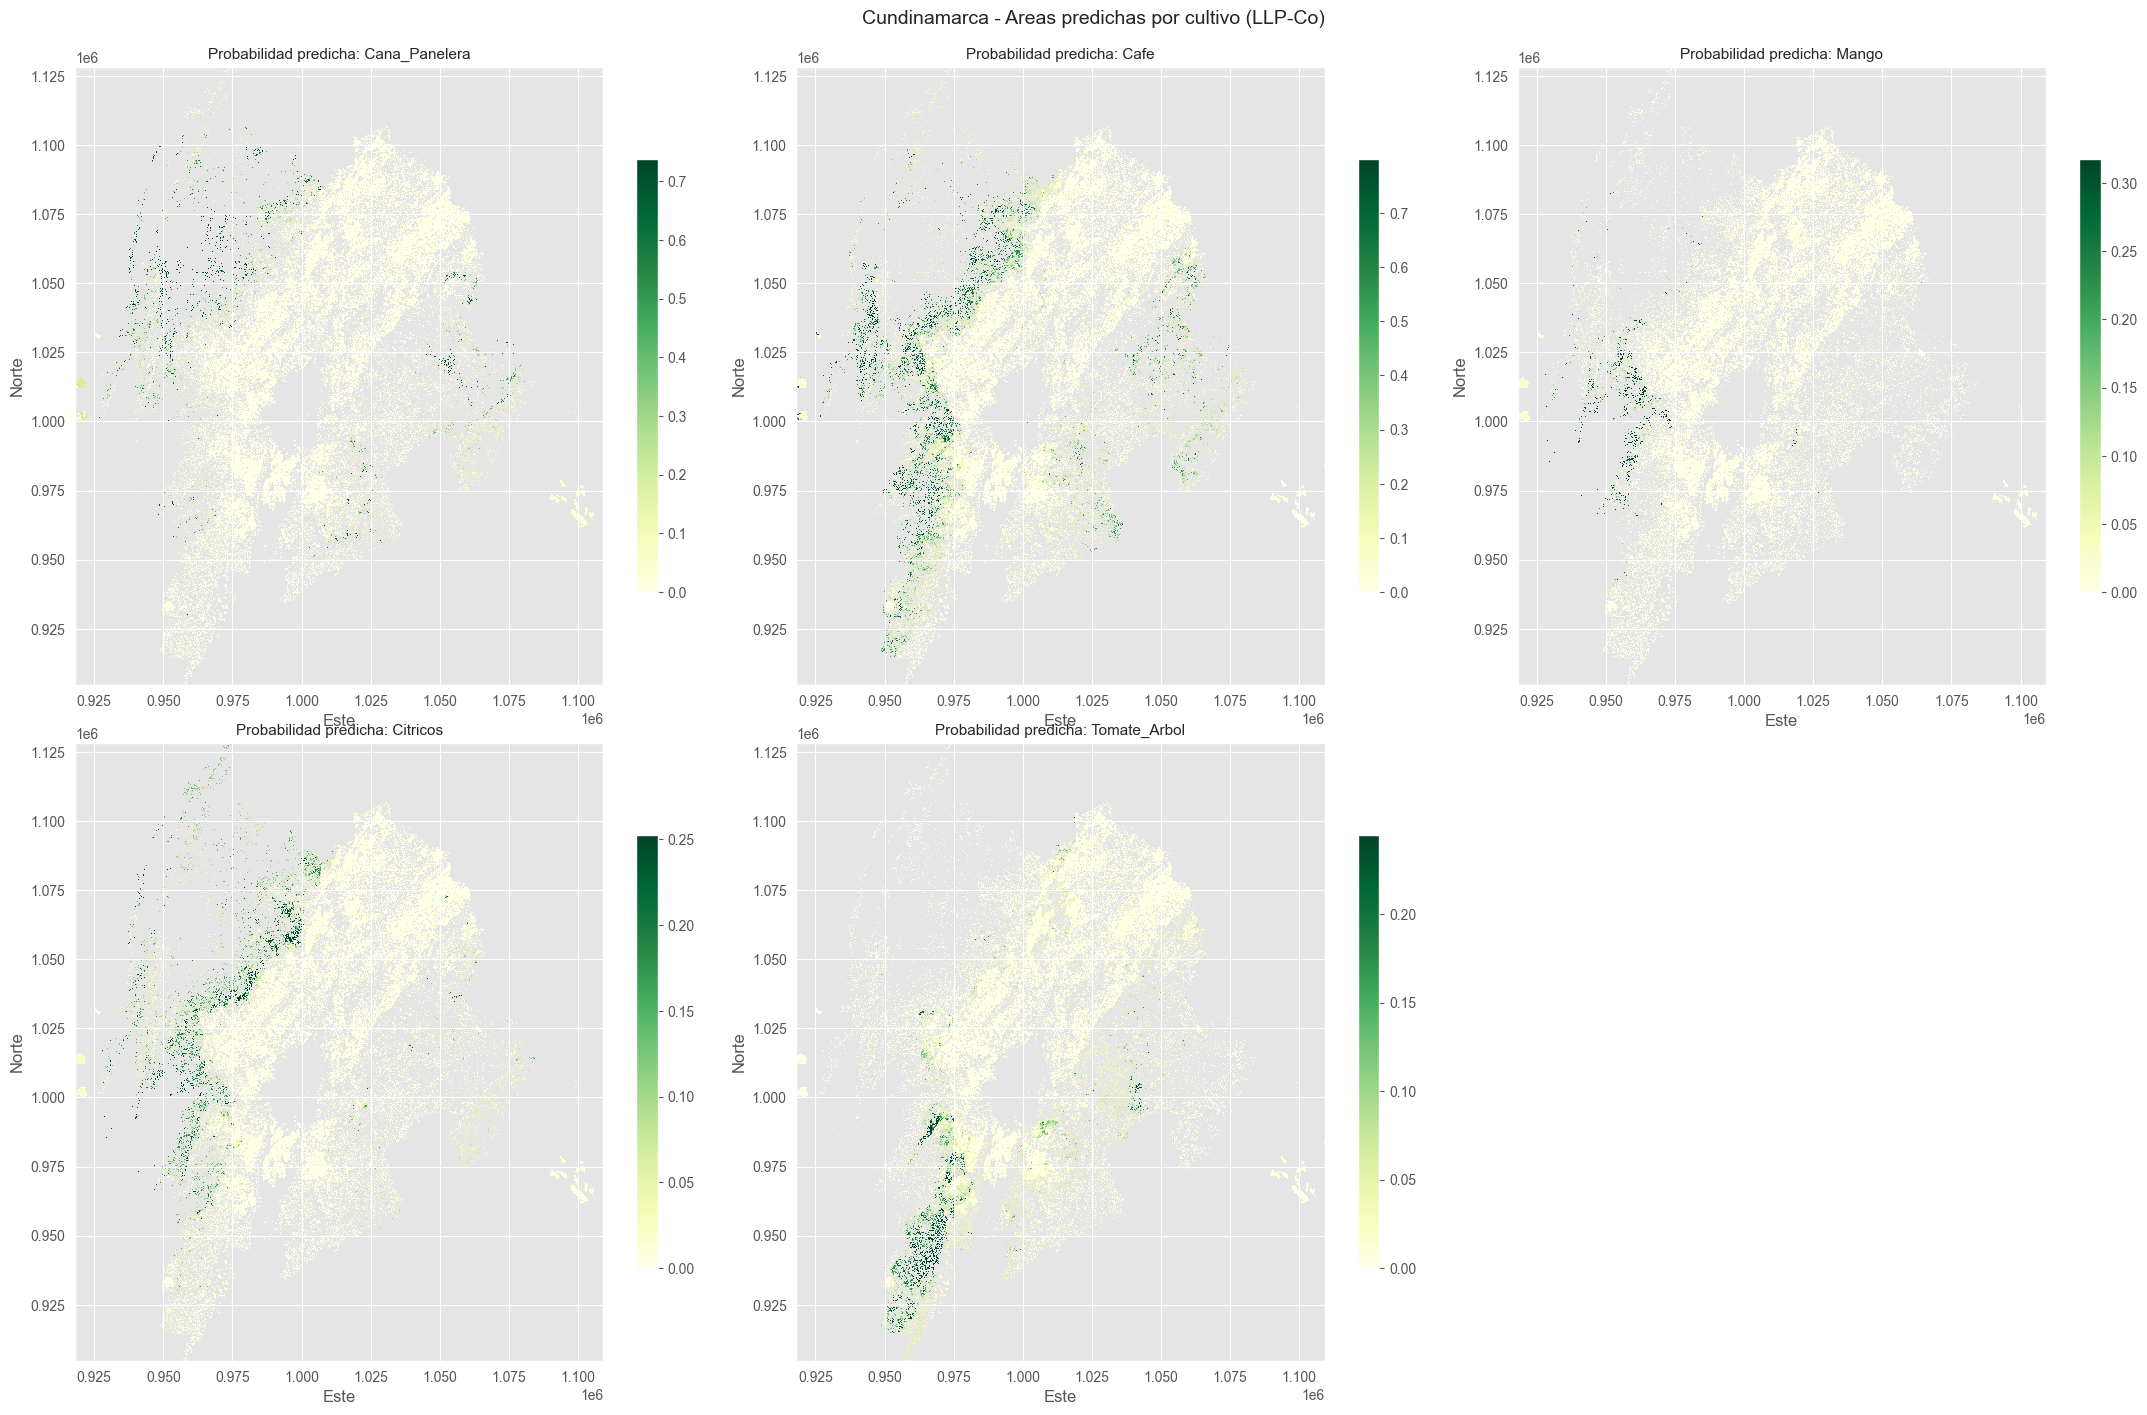

In [49]:
# === Pieza 4: Mapas predichos para Cana, Cafe, Mango, Citricos y Tomate_Arbol ===
# Un subplot por cultivo, escala viridis_r con maximo individual para resaltar contraste.

cultivos_mapa = ['Cana_Panelera', 'Cafe', 'Mango', 'Citricos', 'Tomate_Arbol']

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten()

for i, cult in enumerate(cultivos_mapa):
    cls_idx = catalogo[cult]
    prob_cult = P_full[:, cls_idx]
    grid_c, ext_c = pixel_grid(x_arr, y_arr, prob_cult, resolution=250)

    vmax = float(np.nanpercentile(grid_c, 99))
    vmax = max(vmax, 0.10)
    im = axes[i].imshow(grid_c, extent=ext_c, cmap='YlGn', vmin=0, vmax=vmax,
                        origin='upper', interpolation='nearest')
    axes[i].set_title(f'Probabilidad predicha: {cult}', fontsize=11)
    axes[i].set_xlabel('Este'); axes[i].set_ylabel('Norte')
    plt.colorbar(im, ax=axes[i], shrink=0.7)

# Ocultar el 6to subplot (no usado)
axes[5].set_visible(False)

plt.suptitle('Cundinamarca - Areas predichas por cultivo (LLP-Co)',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

Tabla de caracteristicas promedio por cultivo (top 15 features):
               n_pixeles  elevacion  pendiente  piso_termico  temperatura_media  amplitud_termica  humedad_media  chirps_acum  anomalia_precip  indice_aridez  sg_phh2o  sg_soc  sg_clay  sg_sand  indice_fertilidad  s2_ndvi_media  s2_ndvi_max  s2_ndvi_std  s2_msavi_media  ndvi_sigma_temporal
cultivo                                                                                                                                                                                                                                                                                           
Cana_Panelera      31513  1708.8430    30.0820        1.2010             6.6810            3.4600        76.4660     919.8700           0.0210         4.2490    5.2620  8.2810  33.1620  33.1910             0.5660     -2499.9990       0.7690    3193.6870      -2500.1760               0.0700
Cafe              122394  2096.2510    25.7080        1.6710  

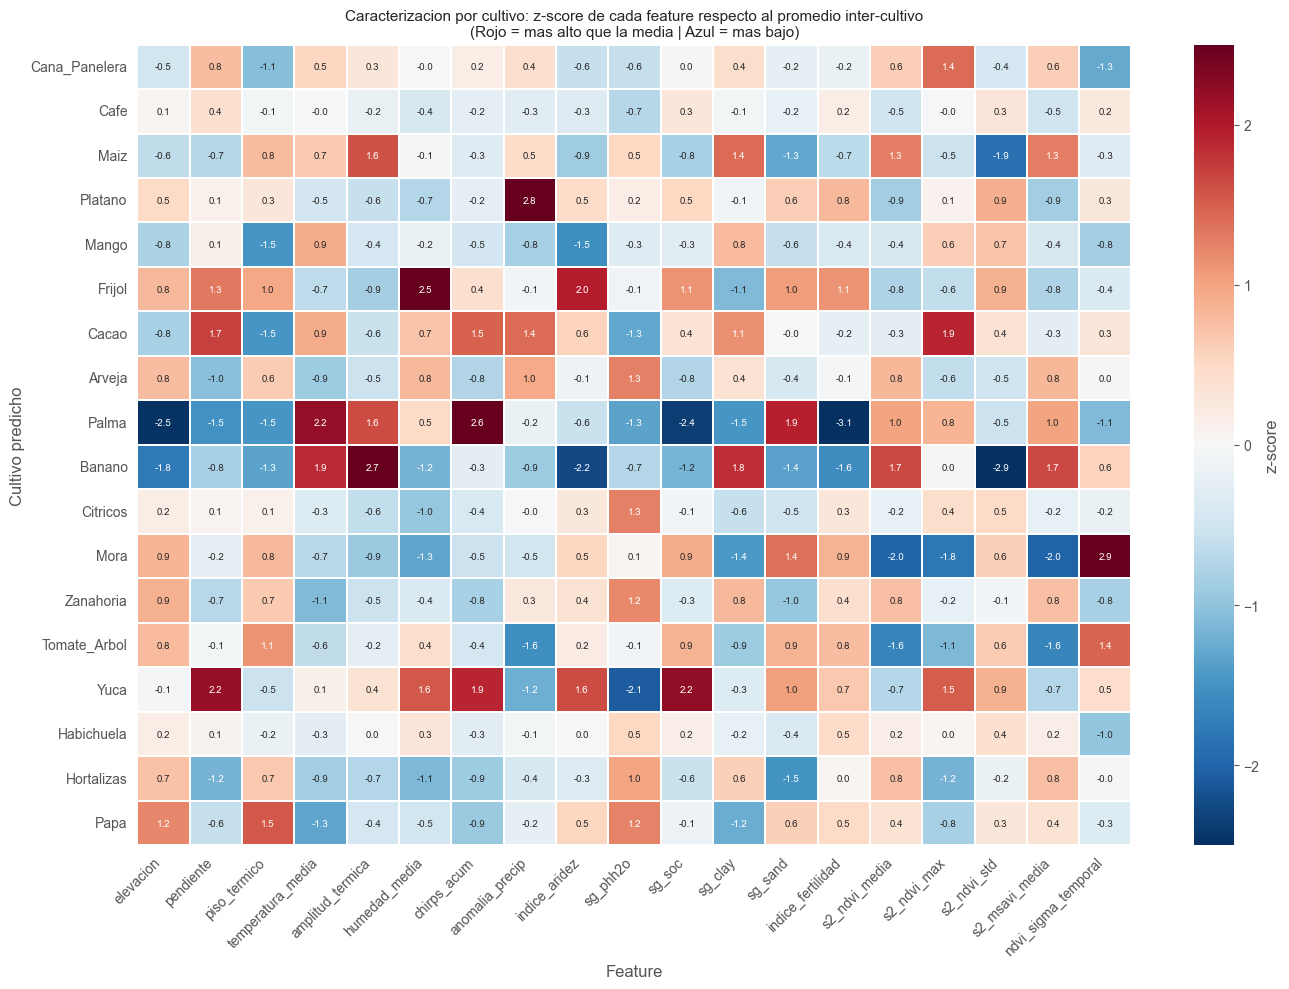

In [40]:
# === Pieza 5: Caracterizacion de cultivos por features promedio ===
# Para cada cultivo: media de cada feature en pixeles donde argmax(P_full)==cultivo.
# Se usan features ORIGINALES (sin estandarizar) para interpretabilidad.

# Subset de features mas relevantes para reporte (clima + topografia + suelo + NDVI)
feature_subset = [
    'elevacion', 'pendiente', 'piso_termico', 'temperatura_media', 'amplitud_termica',
    'humedad_media', 'chirps_acum', 'anomalia_precip', 'indice_aridez',
    'sg_phh2o', 'sg_soc', 'sg_clay', 'sg_sand', 'indice_fertilidad',
    's2_ndvi_media', 's2_ndvi_max', 's2_ndvi_std', 's2_msavi_media', 'ndvi_sigma_temporal',
]
feature_subset = [f for f in feature_subset if f in df_l2.columns]

# Tabla: filas=cultivos, columnas=features, valores=media
rows = []
for cls_id in range(K_FINAL):
    mask = y_full_pred == cls_id
    n = int(mask.sum())
    if n == 0:
        continue
    row = {'cultivo': inv_catalogo[cls_id], 'n_pixeles': n}
    for f in feature_subset:
        vals = df_l2.loc[mask, f].values
        vals = vals[~np.isnan(vals)]
        row[f] = float(vals.mean()) if len(vals) > 0 else np.nan
    rows.append(row)

tabla = pd.DataFrame(rows).set_index('cultivo')
print('Tabla de caracteristicas promedio por cultivo (top 15 features):')
print(tabla.round(3).to_string())
print()

# Heatmap z-score por columna (que features distinguen cada cultivo)
tabla_z = tabla[feature_subset].copy()
for c in tabla_z.columns:
    mu = tabla_z[c].mean()
    sd = tabla_z[c].std()
    tabla_z[c] = (tabla_z[c] - mu) / max(sd, 1e-8)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(tabla_z, cmap='RdBu_r', center=0, vmin=-2.5, vmax=2.5,
            annot=True, fmt='.1f', annot_kws={'size': 7}, cbar_kws={'label': 'z-score'},
            linewidths=0.3, ax=ax)
ax.set_title('Caracterizacion por cultivo: z-score de cada feature respecto al promedio inter-cultivo\n'
             '(Rojo = mas alto que la media | Azul = mas bajo)', fontsize=11)
ax.set_xlabel('Feature'); ax.set_ylabel('Cultivo predicho')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 6. Conclusiones y siguientes pasos

### Resumen del modelo
- Encoder MLP (256→128→64→512) + **K=18 prototipos** en ℝ^{512} (uno por clase L2).
- Bags dinámicos: cada municipio se samplea con `BAG_SIZE=2048` píxeles aleatorios por epoch.
- Sinkhorn-Knopp con prior `w_mun` (proporción EVA agregada del municipio).
- Hiperparámetros optimizados con Optuna (7 params, 100 trials): KL_valid=0.5184.
- Pesos guardados en `checkpoints/l2_llp_co.pt`.

### Resultados de evaluación (modelo final)
| Métrica | Valid | Test |
|---------|-------|------|
| KL_valid (media) | 0.5002 | — |
| KL_valid (mediana) | 0.3610 | — |
| Top-1 Accuracy | 0.5397 | 0.8770 |
| Top-3 Accuracy | 0.8225 | 0.9594 |
| Top-5 Accuracy | 0.8957 | 0.9836 |
| Recall Papa @1 (UPRA) | 0.737 | — |
| Recall Papa @3 (UPRA) | 0.973 | — |

### Hiperparámetros optimizados (Optuna trial #562)
| Hiperparámetro | Valor óptimo |
|----------------|-------------|
| `TAU` | 0.1279 |
| `EPS_SK` | 0.0930 |
| `SIGMA_AUG` | 0.0326 |
| `LR_INIT` | 0.0921 |
| `KOLEO_WEIGHT` | 0.2012 |
| `P_DROP_AUG` | 0.2039 |
| `WEIGHT_DECAY` | 4.38e-4 |

### Métricas a mirar en próximas iteraciones
1. `KL_valid` (objetivo: bajar): debe descender y estabilizarse.
2. `F1_macro` pixel (objetivo: subir): proxy de separabilidad por clase.
3. Similitud entre prototipos (objetivo: cercana a 0 off-diagonal): clases bien separadas.
4. Recall por clase: Maiz, Frijol y Hortalizas tienen R@1 < 0.1 — prioritarios para mejora.
